# When Imbalance Correction Backfires
### Robustness of Tabular Imbalance Mitigation Under Minority-Label Contamination

**Source document:** `finaldraft.pdf` (Research Project Blueprint, prepared Aug 12, 2026)

**Status of source doc:** Experimental protocol only — no empirical results have been generated yet. This notebook is a working reference for the plan, plus placeholder cells to build the implementation into as you go.

---

This notebook summarizes the blueprint step by step, then provides empty skeleton cells matching the paper's proposed repository structure (Section 13.1) so code can be added directly here as the study progresses.

## 1. The Core Question

Standard imbalance-correction techniques (SMOTE, oversampling, class weighting, TabPFN threshold correction, DistPFN) all implicitly assume that when a training example is labeled "minority class," that label is trustworthy.

**This study asks:** what happens to these corrections when that assumption breaks — i.e., when the rare-class labels themselves are corrupted, not just imbalanced? Specifically: *when do imbalance corrections help, stop helping, or become actively harmful, and does the answer differ depending on the direction of the label corruption?*

### Why it's novel (without overclaiming)
The paper explicitly does **not** claim that "class imbalance + label noise" is a new problem — CLIMB, TILBench, and Robust-GBDT already cover that broadly. The narrower, defensible contribution is testing whether the **correction mechanism itself** becomes unreliable under two specific, directed rare-label error processes, and identifying the point at which each correction crosses from helpful to harmful.

## 2. The Two Directed Label-Error Mechanisms

The central methodological idea: split label corruption into two mechanisms and analyze them **separately**, since they are expected to break corrections in different ways.

| | Direction A — Majority → Minority Contamination | Direction B — Minority → Majority Label Loss |
|---|---|---|
| **What happens** | Majority examples get mislabeled as minority | True minority examples get mislabeled as majority |
| **Effect on observed prior** | Inflated (looks like more minority examples exist) | Deflated (looks like fewer minority examples exist) |
| **Risk to corrections** | SMOTE/oversampling/weighting may amplify the false minority examples | Genuine rare examples are lost before correction can use them |
| **c parameter meaning** | Fraction of the *observed* minority-labeled pool that is actually majority | Fraction of *true* minority labels that are omitted |

`c = 0` is a single shared clean condition used by both directions.

## 3. Controlled Experimental Grid

| Factor | Levels |
|---|---|
| Datasets | 5 public UCI datasets (Banknote Authentication, Blood Transfusion, South German Credit, Spambase, Breast Cancer Wisconsin Diagnostic) |
| True minority prevalence *r* | 0.50, 0.20, 0.10, 0.05 |
| Directed noise level *c* | 0, 0.05, 0.10, 0.20, 0.30 (per direction; c=0 shared) |
| Label-error direction | A (maj→min), B (min→maj) |
| Random seeds | 13, 37, 73 |
| Correction pipelines | 9 core + oracle-prior diagnostics |

**Key design controls:**
- Constant clean training size (`N_common`) across all imbalance levels *r*, so imbalance is never confounded with total sample size.
- A single clean, untouched test set per dataset/seed, shared across every condition.
- Corrections are applied *after* the directed label error, exactly as a practitioner would encounter it.

**Estimated workload:** 540 unique dataset-seed-stress contexts → ~3,240 fit/inference jobs → ~4,860 evaluated method-condition rows.

## 4. Correction Strategies Under Test

| Pipeline | What it does |
|---|---|
| TabPFN – none | Uncorrected TFM reference |
| TabPFN – threshold | Classify minority if p(y=1) > observed minority prior (McDowell et al.) |
| TabPFN – downsample | Downsample majority to 1:1 before running TabPFN |
| DistPFN | Posterior adjustment using observed training prior |
| DistPFN-T | Adaptive/temperature-scaled version of DistPFN |
| XGBoost – none | Classical baseline, no correction |
| XGBoost – weighted | `scale_pos_weight` from observed noisy class counts |
| XGBoost – random oversampling | Duplicate observed minority rows |
| XGBoost – SMOTE | Synthetic minority oversampling on training fold only |

**Oracle-prior diagnostic (not deployable):** for threshold/DistPFN/DistPFN-T, rerun using the *true* pre-contamination prior instead of the corrupted observed prior. This isolates how much of any correction failure is caused specifically by prior distortion.

## 5. New Contribution Metrics (Section 10 of the blueprint)

These are the paper's real empirical contribution beyond just running experiments:

- **Correction Gain (CG)** — `score(corrected) - score(uncorrected)` for the same dataset/seed/r/c/direction cell. Sign-flipped for loss metrics so positive always means "helped."
- **Correction Harm Rate (CHR)** — fraction of evaluated cells where CG < 0 (i.e., how *often* a correction hurts).
- **Correction Break-Even Point (c\*)** — smallest noise level *c* at which CG drops to ≤ 0 for a given method/direction.
- **Regret** — `max(0, uncorrected_score - corrected_score)` (how *badly* it hurts when it does).
- **Prior Sensitivity Gap (PSG)** — `oracle_prior_score - observed_prior_score`; a positive gap implicates prior corruption as the cause of failure.

## 6. Evaluation Metrics

**Discrimination (primary):** Balanced Accuracy, Worst-Class Accuracy/Recall, AUPRC, Macro-F1

**Diagnostic:** Minority precision/recall, AUROC (secondary — can conceal rare-class failure)

**Reliability:** Brier score, Log loss, Expected Calibration Error (ECE)

Hypothesis H5: calibration/reliability metrics often reveal correction harm *before* AUROC does — i.e., a model can keep ranking well while its probabilities become untrustworthy.

## 7. Three-Day Execution Schedule

| Day | Objective | Stop condition |
|---|---|---|
| **Day 1** | Freeze protocol; get one dataset running end-to-end | `raw_runs.csv` produced correctly for one dataset × one seed × all 36 stress cells |
| **Day 2** | Complete evidence and freeze results | Full core matrix run, both directions; CG/CHR/regret/break-even/PSG computed; all figures/tables generated |
| **Day 3** | Write the manuscript around verified results | Methods → Results → Intro/Related Work → Discussion → Threats → Abstract (last); every number traced to CSV |

**Runtime fallback rule:** if compute becomes the bottleneck, drop optional methods (CatBoost/ITBoost) first, then oracle diagnostics — never cherry-pick datasets based on performance.

## 8. Reproducibility & Research-Integrity Rules

- No result value enters the paper until it exists in the frozen results files — no placeholder/hypothetical numbers.
- No test-set tuning; the clean test set is only for final evaluation.
- No post-hoc model/checkpoint switching after results are seen.
- No silent failure deletion — `failures.csv` is part of the reproducibility package.
- No cherry-picking — dataset/method removal must be pre-defined and documented *before* comparing results.
- Every noisy run must log its label-error direction, requested/realized rate, flipped-label indices, and prior values.
- Literature search must be refreshed immediately before submission.

## 9. Datasets

| Dataset | UCI ID | N | Features | Domain | Link | DOI |
|---|---|---|---|---|---|---|
| Banknote Authentication | 267 | 1,372 | 4 | Counterfeit vs genuine banknote | [archive.ics.uci.edu/dataset/267](https://archive.ics.uci.edu/dataset/267/banknote+authentication) | 10.24432/C55P57 |
| Blood Transfusion Service Center | 176 | 748 | 4 | Donor donated in target period | [archive.ics.uci.edu/dataset/176](https://archive.ics.uci.edu/dataset/176/blood+transfusion+service+center) | 10.24432/C5GS39 |
| South German Credit | 522 | 1,000 | 20 | Credit risk: good vs bad | [archive.ics.uci.edu/dataset/522](https://archive.ics.uci.edu/dataset/522/south+german+credit) | 10.24432/C5X89F |
| Spambase | 94 | 4,601 | 57 | Spam vs non-spam email | [archive.ics.uci.edu/dataset/94](https://archive.ics.uci.edu/dataset/94/spambase) | 10.24432/C53G6X |
| Breast Cancer Wisconsin (Diagnostic) | 17 | 569 | 30 | Malignant vs benign diagnosis | [archive.ics.uci.edu/dataset/17](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) | 10.24432/C5DW2B |

**Note:** South German Credit (UCI 522) is not importable via the `ucimlrepo` Python package (`fetch_ucirepo(id=522)` raises `DatasetNotFoundError`). Its actual data file must be downloaded directly from `https://archive.ics.uci.edu/static/public/522/south+german+credit.zip` and parsed from the bundled `SouthGermanCredit.asc` file instead.

## 10. Key References

- **CLIMB** — Liu et al., NeurIPS 2025 (Datasets & Benchmarks), arXiv:2505.17451
- **TILBench** — Liu & Luo, arXiv:2605.14915, May 2026
- **PFN imbalance correction (threshold/downsample)** — McDowell et al., arXiv:2605.21742v1, May 2026
- **DistPFN / DistPFN-T** — Lee et al., ICML 2026; arXiv:2605.04363v2
- **Noise Immunity in TabPFN** — Hu & Ghelichi, arXiv:2604.04868, Apr 2026
- **ITBoost** — Su et al., arXiv:2605.04671, May 2026
- **Uncertainty benchmark** — De Melo Costa et al., ESANN 2026
- **SkillTFM** — He et al., arXiv:2608.06137, Aug 2026

Full reference list with DOIs is in Section 19 of `finaldraft.pdf`.

## 11. Next Steps — Step-by-Step Implementation Plan

Adapted from the blueprint's execution protocol (Section 14.1, Steps 1–45), reorganized into 12 phases and mapped onto the notebook sections in **Implementation Skeleton** below (10.1–10.10) so each phase has a home to write code in. Everything happens inside this notebook — no separate repo/`src/` files. Check items off as they're done; log what actually happened in the **Daily Diary** section at the bottom.

### Phase 1 — Environment (→ notebook section 10.1)
- [x] Install in this kernel: numpy, pandas, scipy, scikit-learn, matplotlib, xgboost, tabpfn, imbalanced-learn, ucimlrepo, statsmodels, tqdm, pyyaml
- [x] Record environment identity in a cell: package versions, OS, CPU/GPU, TabPFN checkpoint/model identifier, and the three seeds (13, 37, 73) *(Step 4)*
- [x] Freeze this identity before looking at any comparative results — never change the TabPFN checkpoint after seeing results

### Phase 2 — Data (→ 10.2)
- [x] Fetch UCI IDs 267, 176, 522, 94, 17 (522 needs the direct-zip workaround documented in Section 9 above) *(Step 5)*
- [x] Audit each dataset: row count, feature count, dtypes, duplicate-row count, missing values per column, raw target values/counts *(Step 6)*
- [x] Resolve target semantics from official docs — not assumption — and fix one positive/minority class per dataset, encoded as 1 *(Step 7)*
- [x] Save a machine-readable dataset manifest (raw counts, missing values, any transformations) *(Section 4.1)*

### Phase 3 — Splits & Controlled Imbalance (→ 10.3)
- [x] For seeds 13/37/73, create one stratified 80/20 clean train/test split per dataset, **before** any imbalance or label error *(Step 8)*
- [x] Freeze the test set: never resample, corrupt, or tune on it; must stay byte-identical across every r/c/direction/method *(Step 9)*
- [x] Compute `N_common` per dataset/seed so every r uses the same total clean training size *(Step 10)*
- [x] Build each controlled imbalance set for r ∈ {0.50, 0.20, 0.10, 0.05} by sampling `N_common` rows *(Step 11)*
- [x] Verify: exact size, correct minority/majority counts, no overlap with test set, identical `N_common` across r *(Step 12)*

### Phase 4 — Directed Label-Error Injection (→ 10.5)
- [x] For c=0, store one shared clean condition (no direction-specific duplicate needed)
- [x] For c ∈ {0.05, 0.10, 0.20, 0.30}, generate **both** Direction A and Direction B noisy-label copies from the same clean controlled rows *(Step 13)*
- [x] Verify mathematically: at c=0 labels are identical; Direction A → π_obs ≥ π_true; Direction B → π_obs ≤ π_true *(Step 14)*
- [x] Confirm every competing correction method reuses the identical noisy labels for a given dataset/seed/r/c/direction cell — never redraw per method *(Step 15)*

### Phase 5 — Leakage-Safe Preprocessing (→ 10.4)
- [x] Fit numeric median imputation / categorical imputation+one-hot encoding on the current training condition only; apply to the fixed test set; unknown test categories are ignored, never learned *(Step 16)*

### Phase 6 — Correction Methods: TabPFN Family (→ 10.6)
- [x] Implement frozen TabPFN baseline; save raw P(y=1) on test rows so post-hoc corrections can reuse it *(Step 17)*
- [x] Implement threshold correction (classify minority if p > π_obs) + oracle-π_true diagnostic, clearly labeled non-deployable *(Step 18)*
- [x] Implement TabPFN downsampling (balance observed majority to 1:1, rerun TabPFN) *(Step 19)*
- [x] Implement DistPFN exactly per the paper formula; unit-test probabilities sum to 1; sanity-check against official code on a toy example *(Step 20)*
- [x] Implement DistPFN-T exactly per the paper formula; **validate against official code before full runs** *(Step 21)* — validated against github.com/seunghan96/DistPFN (2026-08-18): the blueprint's paper-derived formula (per-row squaring) turned out to be a mistranscription of the real algorithm (batch-average P_test_avg); DistPFN and DistPFN-T were both rewritten to match the official code exactly (see 10.6). A genuine shape bug in the authors' own DistPFN-T reference driver was found and corrected while preserving the algorithm's clear intent. **All prior DistPFN/DistPFN-T results (raw_runs.csv onward) were computed with the old, incorrect formula and are now stale — re-running the full matrix is required.**
- [x] Wire up observed-prior vs oracle-prior diagnostic variants for threshold/DistPFN/DistPFN-T → this becomes the Prior Sensitivity Gap *(Step 22)*

### Phase 7 — Correction Methods: XGBoost Family (→ 10.7)
- [x] Implement frozen XGBoost baseline — one fixed config used for every variant, no per-condition tuning *(Step 23)*
- [x] Implement weighted XGBoost (`scale_pos_weight` from observed noisy class counts) *(Step 24)*
- [x] Implement RandomOverSampler + XGBoost (training-fold only) *(Step 25)*
- [x] Implement SMOTE + XGBoost (training-fold only; deterministic `k_neighbors` reduction or mark the cell failed if mathematically infeasible, never silently change the design) *(Step 26)*
- [ ] Optional, only after the core matrix exists: CatBoost/ITBoost sanity baselines *(Step 27)*

### Phase 8 — Metrics Module (→ 10.8)
- [x] Implement balanced accuracy, worst-class accuracy/recall, AUPRC, macro-F1, minority precision/recall, AUROC, Brier score, log loss, ECE (fixed bin count, documented) in one tested module *(Step 28)*
- [x] Define score direction consistently: for loss-type metrics (Brier/log loss), flip the sign so positive gain always means "correction helped" *(Step 29)*

### Phase 9 — Contribution Metrics (→ 10.9)
- [x] Compute Correction Gain, Correction Harm Rate, Regret, break-even c*, and Prior Sensitivity Gap — separately per direction, before any cross-direction synthesis *(Step 37, Section 10)* — formulas implemented and unit-tested; not yet applied to real aggregated results (needs the full 5-dataset matrix + summary.csv first)

### Phase 10 — Unit Tests & Smoke Test (→ 10.10–10.12)
- [x] Run all unit tests: c=0 identity, realized-rate tolerance, `N_common` consistency across r, no train/test overlap, DistPFN normalization *(Step 30)*
- [x] One-cell smoke test: one dataset, one seed, one r, one nonzero c, both directions, all core methods + the shared c=0 cell *(Step 31)*
- [x] One-dataset pilot: all 36 unique stress cells × 3 seeds for one dataset — inspect only for bugs/leakage/runtime, **not** to pick a favorite method *(Step 32)* — complete: 108 stress-cell-seed combinations, 1284 result rows, 12 failures (all one understood, documented edge case — see 10.12)
- [ ] Freeze the protocol (config + notebook state/commit) once the pilot is technically correct — any later change must be documented with a reason *(Step 33)*

### Phase 11 — Full Run & Analysis (→ 10.13 for figures; full matrix not yet built)
- [ ] Run the full core matrix: 5 datasets × 3 seeds × 36 stress contexts × 9 pipelines (540 stress contexts, ~4,860 evaluated method-context rows) *(Step 34)*
- [x] Log failures to a `failures` table with method/dataset/condition/reason rather than silently dropping cells *(Step 35)* — done for the pilot; same mechanism scales to the full matrix
- [ ] Build the frozen summary table — aggregate seeds within each dataset-method-r-c-direction cell *(Step 36)*
- [ ] Run planned statistics: paired-block Friedman omnibus test, then paired Wilcoxon signed-rank tests with Holm correction; report effect sizes, not just p-values *(Step 38)*
- [ ] Generate all required figures/tables (Section 12 of the blueprint) directly from the frozen data — never hand-typed values *(Step 39)*
- [ ] Interpret without forcing the hypothesis — report negative or dataset-heterogeneous results exactly as they come out *(Step 40)*

### Phase 12 — Manuscript (Day 3 equivalent)
- [ ] Write Methods first — must be reproducible without looking at the result tables *(Step 41)*
- [ ] Write Results directly from frozen outputs, answering RQ1–RQ5 in order, keeping Direction A/B separate unless an aggregate is explicitly defined *(Step 42)*
- [ ] Write Discussion with bounded claims — distinguish "correction hurts" from "base model fails," compare to McDowell/DistPFN/noise literature *(Step 43)*
- [ ] Refresh the literature search immediately before submission; revise the novelty paragraph if something new overlaps *(Step 44)*
- [ ] Final reproducibility/integrity audit — rerun sampled cells, rebuild figures from raw results, verify citations, remove any placeholder values *(Step 45)*

---
## Implementation Skeleton

The cells below mirror the proposed repository structure (Section 13.1). Fill these in as you start Day 1 work. They are currently empty placeholders.

### 10.1 Environment setup

In [2]:
"""
Section 10.1 — Environment setup.

Three things happen here:
1. Import every library the study needs and confirm they're actually installed.
2. Define the constants that stay fixed for the entire study (project paths, the
   3 random seeds, the 4 imbalance ratios, the 5 noise levels, the 2 label-error
   directions) so every later cell references the same frozen values instead of
   re-typing magic numbers.
3. Print the exact package versions in use. This is not decorative — the blueprint
   (Step 4) requires the software environment to be recorded and frozen *before*
   any comparative result is generated, so a later reviewer can reproduce the run.
"""

# CRITICAL: must run before numpy/xgboost/tabpfn(torch) are imported anywhere in this
# kernel. XGBoost and PyTorch (which TabPFN depends on) each bundle their own OpenMP/BLAS
# runtime; running an XGBoost fit followed by a TabPFN fit in the SAME process without this
# would hang indefinitely (or in the reverse import order, segfault) on this machine — a
# real binary conflict between the two libraries' threading runtimes, reproduced and
# confirmed via isolated testing outside this notebook. Forcing every backend to a single
# thread avoids the conflict entirely; for this study's dataset sizes (hundreds to a few
# thousand rows per fit) the performance cost of single-threading is negligible.
import os
for _var in ["OMP_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS"]:
    os.environ.setdefault(_var, "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import hashlib
import json
import math
import os
import platform
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
import xgboost
import imblearn
import tabpfn

# PROJECT_ROOT assumes the notebook's working directory is the project root
# (where the data/ folder lives). DATA_DIR points at the processed CSVs and
# the manifest built in the earlier data-preparation step.
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

# Load TABPFN_TOKEN from a local, untracked .env file rather than hardcoding the
# secret into this notebook — the key never gets written into a file that might
# later be shared/published/committed. os.environ.setdefault() means a token
# already exported in the shell always takes priority over the .env file.
env_path = PROJECT_ROOT / ".env"
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            key, _, value = line.partition("=")
            os.environ.setdefault(key.strip(), value.strip())

# --- Frozen experimental design constants (blueprint Section 5.1) ---
SEEDS = [13, 37, 73]                              # 3 random seeds -> every stress cell is repeated 3x
R_VALUES = [0.50, 0.20, 0.10, 0.05]                # true minority prevalence, balanced -> severe
C_VALUES = [0.00, 0.05, 0.10, 0.20, 0.30]          # directed label-error rate; c=0 is the shared clean case
DIRECTIONS = ["majority_to_minority", "minority_to_majority"]  # the two corruption mechanisms (Direction A / B)

# ENV_INFO is what gets logged/printed for reproducibility. Anyone re-running this
# notebook later can diff their own printed versions against this to see if the
# environment drifted.
ENV_INFO = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "scipy": scipy.__version__,
    "xgboost": xgboost.__version__,
    "imbalanced-learn": imblearn.__version__,
    "statsmodels": statsmodels.__version__,
    "tabpfn": tabpfn.__version__,
    "seeds": SEEDS,
}
for k, v in ENV_INFO.items():
    print(f"{k:18s}: {v}")

if os.environ.get("TABPFN_TOKEN"):
    print(f"{'TABPFN_TOKEN':18s}: set")
else:
    print(f"{'TABPFN_TOKEN':18s}: NOT SET — TabPFN model calls (Phase 6) will fail until the license is accepted")

# Frozen checkpoint identity (blueprint Step 4: "record model/checkpoint identifier
# ... do not change checkpoint after inspecting results"). This reads whatever is
# already cached locally rather than forcing a fresh download/fit here — the first
# real .fit() call in 10.5 is what actually downloads it if it isn't cached yet.
try:
    from tabpfn.model_loading import get_cache_dir
    tabpfn_cache_dir = get_cache_dir()
    ckpt_files = sorted(tabpfn_cache_dir.glob("*.ckpt")) if tabpfn_cache_dir.exists() else []
    if ckpt_files:
        for ckpt in ckpt_files:
            sha256 = hashlib.sha256(ckpt.read_bytes()).hexdigest()
            print(f"{'tabpfn checkpoint':18s}: {ckpt.name}")
            print(f"{'checkpoint sha256':18s}: {sha256}")
    else:
        print(f"{'tabpfn checkpoint':18s}: not yet downloaded (fetched on first .fit() call in 10.5)")
except Exception as e:
    print(f"{'tabpfn checkpoint':18s}: could not resolve cache dir ({e})")


/Users/sanju/Library/Python/3.13/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python            : 3.13.5
platform          : macOS-26.5.1-arm64-arm-64bit-Mach-O
numpy             : 2.3.0
pandas            : 3.0.5
scikit-learn      : 1.9.0
scipy             : 1.18.0
xgboost           : 3.4.1
imbalanced-learn  : 0.14.2
statsmodels       : 0.14.6
tabpfn            : 8.3.0
seeds             : [13, 37, 73]
TABPFN_TOKEN      : set
tabpfn checkpoint : tabpfn-v3-classifier-v3_default.ckpt
checkpoint sha256 : d0d865d54dfbc524f5703104be90620182dca7e5fb2c16de72e9959ea18f3988


### 10.1b Additional datasets for external validity (blueprint extension, Session 17)

Extends the study from 5 datasets to 10 by adding 5 more UCI datasets, chosen for
domain and scale diversity beyond what the original 5 cover (security, healthcare,
finance): Ionosphere (signal processing), Haberman's Survival and Statlog Heart
(healthcare), HTRU2 (astronomy, far larger scale than anything else in the study),
and QSAR Biodegradation (chemistry). Run this cell once, before 10.2, which loads
`DATASETS` generically from whatever is in `data/manifest.json`, so nothing
downstream needs to change to pick these up.

In [3]:
"""
Section 10.1b — Data preparation for 5 additional datasets (Session 17).

For each dataset, fetches it, determines its minority/positive class from a cited
source (never guessed, matching Section 4.1's rule for the original 5), writes
data/processed/{slug}_X.csv / _y.csv / _full.csv, and appends an entry to
data/manifest.json. Idempotent: re-running replaces only these 5 slugs' entries,
never touches the original 5.

Four of the five (Ionosphere, Haberman's Survival, Statlog Heart, HTRU2) are fetched
live from the UCI API via ucimlrepo, so this cell needs internet access to run.
QSAR Biodegradation is not importable via ucimlrepo (the same exception already noted
for South German Credit in 10.2), so it is parsed directly from the raw file already
downloaded to data/raw/qsar_biodegradation/biodeg.csv.
"""

from ucimlrepo import fetch_ucirepo


def build_entry_from_ucimlrepo(uci_id, slug, positive_raw_value, positive_meaning, positive_source):
    ds = fetch_ucirepo(id=uci_id)
    X = ds.data.features.copy()
    y_raw = ds.data.targets.iloc[:, 0]
    y = (y_raw == positive_raw_value).astype(int)

    full = X.copy()
    full["target"] = y.to_numpy()
    full["target_raw"] = y_raw.to_numpy()

    raw_counts = y_raw.value_counts()
    entry = {
        "uci_id": uci_id,
        "name": ds.metadata.name,
        "n_rows": len(X),
        "n_features": X.shape[1],
        "feature_columns": X.columns.tolist(),
        "raw_class_counts": {str(k): int(v) for k, v in raw_counts.items()},
        "encoded_minority_count": int(y.sum()),
        "encoded_majority_count": int((y == 0).sum()),
        "duplicate_row_count": int(full.duplicated().sum()),
        "missing_value_counts": {k: int(v) for k, v in X.isnull().sum().items() if v > 0},
        "positive_class": {
            "positive_raw_value": positive_raw_value,
            "meaning": positive_meaning,
            "source": positive_source,
        },
        "uci_url": f"https://archive.ics.uci.edu/dataset/{uci_id}",
        "slug": slug,
        "raw_path": f"data/raw/{slug}/",
        "processed_X": f"data/processed/{slug}_X.csv",
        "processed_y": f"data/processed/{slug}_y.csv",
        "processed_full": f"data/processed/{slug}_full.csv",
    }
    return entry, X, y, full


NEW_DATASET_SPECS = [
    dict(uci_id=52, slug="ionosphere", positive_raw_value="b",
         positive_meaning="radar return with no evidence of ionospheric structure",
         source="official ionosphere.names variable description ('Good radar returns "
                "are those showing evidence of some type of structure in the "
                "ionosphere. Bad returns are those that do not; their signals pass "
                "through the ionosphere.')"),
    dict(uci_id=43, slug="haberman_survival", positive_raw_value=2,
         positive_meaning="patient died within 5 years of surgery",
         source="official UCI variable description ('1 = the patient survived 5 "
                "years or longer, 2 = the patient died within 5 year')"),
    dict(uci_id=145, slug="statlog_heart", positive_raw_value=2,
         positive_meaning="presence of heart disease",
         source="official UCI variable description ('Absence (1) or presence (2) "
                "of heart disease')"),
    dict(uci_id=372, slug="htru2", positive_raw_value=1,
         positive_meaning="pulsar candidate",
         source="official HTRU2 dataset description (1,639 positive examples are "
                "pulsars, 16,259 negative examples are not)"),
]

new_entries = []
for spec in NEW_DATASET_SPECS:
    entry, X, y, full = build_entry_from_ucimlrepo(
        spec["uci_id"], spec["slug"], spec["positive_raw_value"],
        spec["positive_meaning"], spec["source"],
    )
    X.to_csv(PROJECT_ROOT / entry["processed_X"], index=False)
    pd.Series(y, name="target").to_csv(PROJECT_ROOT / entry["processed_y"], index=False)
    full.to_csv(PROJECT_ROOT / entry["processed_full"], index=False)
    new_entries.append(entry)
    print(f"{entry['slug']:24s} n={entry['n_rows']:6d}  features={entry['n_features']:3d}  "
          f"minority={entry['encoded_minority_count']:5d}  majority={entry['encoded_majority_count']:6d}  "
          f"positive={entry['positive_class']['meaning']}")

# QSAR Biodegradation: raw file is semicolon-delimited with no header row. Column
# names and target-value meanings are taken verbatim from the dataset's official
# UCI variable table (archive.ics.uci.edu/dataset/254).
# 8 of the 41 official UCI feature names contain "[" and "]" (e.g. "F01[N-N]"),
# which XGBoost's tree serialization format rejects ("feature_names must be
# string, and may not contain [, ] or <"), the same restriction already
# documented for Spambase's char_freq_[ column in 10.2. Renamed here to the
# bracket-free form (e.g. "F01_N-N"): cosmetic only, values are unchanged.
QSAR_COLUMNS = [
    "SpMax_L", "J_Dz(e)", "nHM", "F01_N-N", "F04_C-N", "NssssC", "nCb-", "C%", "nCp", "nO",
    "F03_C-N", "SdssC", "HyWi_B(m)", "LOC", "SM6_L", "F03_C-O", "Me", "Mi", "nN-N", "nArNO2",
    "nCRX3", "SpPosA_B(p)", "nCIR", "B01_C-Br", "B03_C-Cl", "N-073", "SpMax_A", "Psi_i_1d",
    "B04_C-Br", "SdO", "TI2_L", "nCrt", "C-026", "F02_C-N", "nHDon", "SpMax_B(m)", "Psi_i_A",
    "nN", "SM6_B(m)", "nArCOOR", "nX", "Class",
]
qsar_raw = pd.read_csv(DATA_DIR / "raw" / "qsar_biodegradation" / "biodeg.csv",
                        sep=";", names=QSAR_COLUMNS, header=None)
qsar_X = qsar_raw.drop(columns=["Class"])
qsar_y_raw = qsar_raw["Class"]
qsar_y = (qsar_y_raw == "RB").astype(int)
qsar_full = qsar_X.copy()
qsar_full["target"] = qsar_y.to_numpy()
qsar_full["target_raw"] = qsar_y_raw.to_numpy()

qsar_entry = {
    "uci_id": 254,
    "name": "QSAR biodegradation",
    "n_rows": len(qsar_X),
    "n_features": qsar_X.shape[1],
    "feature_columns": qsar_X.columns.tolist(),
    "raw_class_counts": {str(k): int(v) for k, v in qsar_y_raw.value_counts().items()},
    "encoded_minority_count": int(qsar_y.sum()),
    "encoded_majority_count": int((qsar_y == 0).sum()),
    "duplicate_row_count": int(qsar_full.duplicated().sum()),
    "missing_value_counts": {},
    "positive_class": {
        "positive_raw_value": "RB",
        "meaning": "ready biodegradable",
        "source": "official UCI variable table ('Experimental class: RB = ready "
                  "biodegradable; NRB = not ready biodegradable')",
    },
    "uci_url": "https://archive.ics.uci.edu/dataset/254",
    "slug": "qsar_biodegradation",
    "raw_path": "data/raw/qsar_biodegradation/",
    "processed_X": "data/processed/qsar_biodegradation_X.csv",
    "processed_y": "data/processed/qsar_biodegradation_y.csv",
    "processed_full": "data/processed/qsar_biodegradation_full.csv",
    "transformations": [
        "Renamed 8 features containing '[' and ']' (e.g. 'F01[N-N]' -> 'F01_N-N'): "
        "XGBoost's tree serialization format rejects '[', ']', and '<' in feature "
        "names, causing every XGBoost fit on this dataset to fail with "
        "'feature_names must be string, and may not contain [, ] or <'. Semantic "
        "meaning unchanged; only the column labels changed.",
    ],
}
qsar_X.to_csv(PROJECT_ROOT / qsar_entry["processed_X"], index=False)
pd.Series(qsar_y, name="target").to_csv(PROJECT_ROOT / qsar_entry["processed_y"], index=False)
qsar_full.to_csv(PROJECT_ROOT / qsar_entry["processed_full"], index=False)
new_entries.append(qsar_entry)
print(f"{qsar_entry['slug']:24s} n={qsar_entry['n_rows']:6d}  features={qsar_entry['n_features']:3d}  "
      f"minority={qsar_entry['encoded_minority_count']:5d}  majority={qsar_entry['encoded_majority_count']:6d}  "
      f"positive={qsar_entry['positive_class']['meaning']}")

# Merge into manifest.json: replace any existing entries for these 5 slugs (so this
# cell is safe to re-run), but never touch the original 5 datasets' entries.
with open(DATA_DIR / "manifest.json") as f:
    manifest = json.load(f)

new_slugs = {e["slug"] for e in new_entries}
manifest = [e for e in manifest if e["slug"] not in new_slugs] + new_entries

with open(DATA_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\nmanifest.json now has {len(manifest)} datasets "
      f"({len(manifest) - len(new_entries)} original + {len(new_entries)} new).")


ionosphere               n=   351  features= 34  minority=  126  majority=   225  positive=radar return with no evidence of ionospheric structure
haberman_survival        n=   306  features=  3  minority=   81  majority=   225  positive=patient died within 5 years of surgery
statlog_heart            n=   270  features= 13  minority=  120  majority=   150  positive=presence of heart disease
htru2                    n= 17898  features=  8  minority= 1639  majority= 16259  positive=pulsar candidate
qsar_biodegradation      n=  1055  features= 41  minority=  356  majority=   699  positive=ready biodegradable

manifest.json now has 10 datasets (5 original + 5 new).


### 10.2 Dataset loading and audit (Section 4)

In [4]:
"""
Section 10.2 — Dataset loading and audit (blueprint Section 4).

Loads all 5 UCI datasets from the already-prepared data/manifest.json + data/processed/
CSVs (built in the earlier data-preparation pass) rather than re-downloading from UCI
every time the notebook runs. For each dataset this:
  1. Reads the manifest entry, which records the audited row/feature counts, the raw
     class counts *before* any encoding, and — critically — which raw value was chosen
     as the "positive"/minority class and why (Section 4.1: this must come from a cited
     source, never be guessed).
  2. Loads the processed "_full.csv", which already has a clean 0/1 `target` column
     (minority = 1) plus the original `target_raw` value for traceability.
  3. Splits that into X (features only) and y (the encoded target as a numpy array).
  4. Stores both in the DATASETS dict, keyed by a human-readable slug, so later cells
     can do `DATASETS["banknote_authentication"]["X"]` instead of juggling numeric UCI IDs.
"""

with open(DATA_DIR / "manifest.json") as f:
    MANIFEST = json.load(f)

DATASETS = {}
for entry in MANIFEST:
    slug = entry["slug"]
    full = pd.read_csv(PROJECT_ROOT / entry["processed_full"])
    y = full["target"].to_numpy()                       # encoded target: 1 = minority, 0 = majority
    X = full.drop(columns=["target", "target_raw"])      # feature matrix only
    DATASETS[slug] = {"X": X, "y": y, "meta": entry}
    print(f"{slug:28s} n={entry['n_rows']:5d}  features={entry['n_features']:3d}  "
          f"minority={entry['encoded_minority_count']:4d}  majority={entry['encoded_majority_count']:4d}  "
          f"positive={entry['positive_class']['meaning']}")

# South German Credit note: not importable via ucimlrepo — data/raw/south_german_credit/
# was fetched directly from the UCI static zip and parsed from SouthGermanCredit.asc.
# Banknote Authentication note: UCI metadata does not document the 0/1 class mapping;
# class 1 = forged/counterfeit follows community convention, not an official UCI source.


banknote_authentication      n= 1372  features=  4  minority= 610  majority= 762  positive=forged/counterfeit banknote
blood_transfusion            n=  748  features=  4  minority= 178  majority= 570  positive=donated blood in target period
south_german_credit          n= 1000  features= 20  minority= 300  majority= 700  positive=bad credit risk
spambase                     n= 4601  features= 57  minority=1813  majority=2788  positive=spam email
breast_cancer_wisconsin      n=  569  features= 30  minority= 212  majority= 357  positive=malignant diagnosis
ionosphere                   n=  351  features= 34  minority= 126  majority= 225  positive=radar return with no evidence of ionospheric structure
haberman_survival            n=  306  features=  3  minority=  81  majority= 225  positive=patient died within 5 years of surgery
statlog_heart                n=  270  features= 13  minority= 120  majority= 150  positive=presence of heart disease
htru2                        n=17898  features

### 10.3 Constant training size + controlled imbalance (Section 5.2)

In [5]:
"""
Section 10.3 — Constant training size + controlled imbalance (blueprint Section 5.2).

Why this exists: if you just sampled "20% minority" vs "5% minority" directly from a
fixed pool, the 5% condition would end up with a *smaller total training set* (fewer
minority rows available -> fewer total rows possible), so any performance difference
between imbalance levels could be explained by sample size instead of imbalance itself.
These three functions remove that confound by picking one common total size N_common
that is achievable at every tested r, then sampling exactly N_common rows each time.
"""


def feasible_n(r: float, n_min_available: int, n_maj_available: int) -> float:
    """Largest total sample size achievable at minority ratio r given the two class pools.

    At ratio r, a total size N needs r*N minority rows and (1-r)*N majority rows.
    So N is capped by whichever class runs out first: N <= n_min_available / r
    and N <= n_maj_available / (1-r). This returns the tighter (smaller) of those two caps.

    Args:
        r: target minority prevalence (e.g. 0.20 for 20% minority).
        n_min_available: minority rows available to sample from.
        n_maj_available: majority rows available to sample from.

    Returns:
        The largest N (as a float) for which both class requirements are satisfiable.
    """
    return min(n_min_available / r, n_maj_available / (1.0 - r))


def compute_common_training_size(r_values, n_min_available: int, n_maj_available: int) -> int:
    """The single training size usable across every r in r_values without exceeding
    either class pool at any of them (blueprint Section 5.2).

    Computes feasible_n() at every requested r, then takes the minimum across all of
    them (the tightest constraint wins) and floors it to a whole number of rows.

    Args:
        r_values: list of minority prevalences that will all need to share one N.
        n_min_available: minority rows available (from the training split, pre-imbalance).
        n_maj_available: majority rows available (from the training split, pre-imbalance).

    Returns:
        N_common: an integer row count safe to sample at every r in r_values.
    """
    feasible = [feasible_n(r, n_min_available, n_maj_available) for r in r_values]
    return math.floor(min(feasible))


def sample_controlled_set(r: float, n_common: int, min_idx: np.ndarray, maj_idx: np.ndarray, rng: np.random.Generator):
    """Draw exactly n_common rows at minority prevalence r from the available index pools.

    Splits n_common into round(r * n_common) minority rows and the remainder majority
    rows, samples each class without replacement, concatenates, and shuffles so the
    two classes aren't sitting in two contiguous blocks.

    Args:
        r: target minority prevalence for this sample.
        n_common: total rows to draw (from compute_common_training_size()).
        min_idx: array of row indices belonging to the minority class.
        maj_idx: array of row indices belonging to the majority class.
        rng: numpy random Generator, so sampling is seeded/reproducible by the caller.

    Returns:
        A shuffled numpy array of n_common row indices meeting the target ratio.

    Raises:
        ValueError: if either class pool doesn't have enough rows to satisfy r at
            this n_common (should not happen if n_common came from
            compute_common_training_size() using the same pools).
    """
    n_min = int(round(r * n_common))
    n_maj = n_common - n_min
    if n_min > len(min_idx) or n_maj > len(maj_idx):
        raise ValueError(
            f"r={r}: need n_min={n_min}/n_maj={n_maj} but pools have "
            f"{len(min_idx)}/{len(maj_idx)} available"
        )
    sel_min = rng.choice(min_idx, size=n_min, replace=False)
    sel_maj = rng.choice(maj_idx, size=n_maj, replace=False)
    selected = np.concatenate([sel_min, sel_maj])
    rng.shuffle(selected)  # avoid a block of all-minority followed by all-majority rows
    return selected


### 10.4 Leakage-Safe Preprocessing & Stratified Split (Phase 5, Section 8)

In [6]:
"""
Section 10.4 — Leakage-safe preprocessing & stratified split (Phase 5, blueprint Section 8).

Two leakage risks this guards against:
1. Split leakage: if you preprocess (impute/encode) before splitting train/test, the
   imputer's median or the encoder's category list is influenced by test rows the model
   should never see. stratified_split() always runs first, before any fitting.
2. Fit leakage within a stress condition: fit_preprocessing() must only ever be fit on
   the *current* training condition (after imbalance + label-error injection), and
   apply_preprocessing() is what turns the held-out test set through that same fitted
   transform — never the other way around.
"""

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


def stratified_split(X: pd.DataFrame, y: np.ndarray, seed: int, train_fraction: float = 0.80):
    """One stratified 80/20 clean train/test split, created before any controlled
    imbalance or directed label error is introduced (blueprint Step 8).

    "Stratified" means the train and test sets each preserve the original minority/
    majority ratio of the full dataset — otherwise a random split could accidentally
    put too few (or zero) minority rows in the test set.

    Args:
        X: full feature matrix for one dataset.
        y: full encoded target array (aligned row-for-row with X).
        seed: one of the 3 study seeds (13/37/73); the split is deterministic per seed.
        train_fraction: fraction of rows to place in the training partition.

    Returns:
        (train_idx, test_idx): two numpy arrays of row-position indices into X/y.
        test_idx and its labels must never change after this point for this seed —
        every later r/c/direction/method condition reuses the same test rows.
    """
    train_idx, test_idx = train_test_split(
        np.arange(len(X)), train_size=train_fraction, stratify=y, random_state=seed,
    )
    return train_idx, test_idx


def fit_preprocessing(X_train: pd.DataFrame):
    """Fit imputers/encoders on the current training condition only (Section 8, rules 4-5).

    Splits columns into numeric vs categorical, then:
      - numeric columns: fit a median imputer (fills missing values with the training
        column's median — trees/TabPFN don't need scaling, so no scaler is fit).
      - categorical columns: fit a most-frequent-value imputer, then a one-hot encoder
        with handle_unknown="ignore" so a category never seen in training doesn't crash
        or (worse) get quietly learned from test data later.

    Args:
        X_train: the training feature matrix for the *current* stress condition
            (i.e. after controlled imbalance and label-error injection have already
            picked which rows are in play — this must be called fresh for every
            r/c/direction cell, never fit once and reused).

    Returns:
        A dict bundling the fitted transformers and the column-name lists needed to
        apply them consistently later via apply_preprocessing().
    """
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    numeric_imputer = SimpleImputer(strategy="median")
    if numeric_cols:
        numeric_imputer.fit(X_train[numeric_cols])

    cat_imputer = None
    encoder = None
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        cat_imputer.fit(X_train[categorical_cols])
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        encoder.fit(cat_imputer.transform(X_train[categorical_cols]))

    return {
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "numeric_imputer": numeric_imputer,
        "cat_imputer": cat_imputer,
        "encoder": encoder,
    }


def apply_preprocessing(X: pd.DataFrame, fitted: dict) -> pd.DataFrame:
    """Apply an already-fitted preprocessing bundle to any feature matrix (train or test).

    Unknown test-time categories are ignored (encoded as all-zeros for that column's
    one-hot block), never learned from test data — this is what handle_unknown="ignore"
    guarantees at fit time.

    Args:
        X: feature matrix to transform. Can be the same X_train used to fit, or the
            held-out X_test — the transform logic is identical either way, which is
            the whole point (no separate "test path").
        fitted: the dict returned by fit_preprocessing().

    Returns:
        A new DataFrame: imputed numeric columns unchanged in name, categorical
        columns replaced by their one-hot encoded columns.
    """
    parts = []
    if fitted["numeric_cols"]:
        num = fitted["numeric_imputer"].transform(X[fitted["numeric_cols"]])
        parts.append(pd.DataFrame(num, columns=fitted["numeric_cols"], index=X.index))
    if fitted["categorical_cols"]:
        cat_imputed = fitted["cat_imputer"].transform(X[fitted["categorical_cols"]])
        cat_encoded = fitted["encoder"].transform(cat_imputed)
        enc_cols = fitted["encoder"].get_feature_names_out(fitted["categorical_cols"])
        parts.append(pd.DataFrame(cat_encoded, columns=enc_cols, index=X.index))
    return pd.concat(parts, axis=1)


### 10.5 Directed Label-Error Functions (Section 6 / 13.4)

In [7]:
"""
Section 10.5 — Directed label-error functions (blueprint Section 6 / 13.4).

These two functions ARE the study's central manipulation. Everything else in this
notebook exists to measure what happens when one of these runs. They take a set of
clean (trustworthy) labels and corrupt a controlled fraction of them in one of two
directions, then hand back the corrupted labels plus a record of exactly what changed
so the corruption is fully auditable.
"""


def majority_to_minority_contamination(y_clean: np.ndarray, c: float, rng: np.random.Generator):
    """Direction A: flip true-majority (0) rows to minority (1).

    Models the failure mode where majority examples get mislabeled as the rare class
    (e.g. an annotator wrongly flags a normal transaction as fraud). c is defined
    relative to the *observed* minority pool, not the clean one: c is the fraction of
    labels that will *look* minority after corruption but are actually majority.

    Derivation of k (how many majority rows to flip):
        We want:  k / (n_min + k) = c        (k fake-minority rows among the observed pool)
        Solving for k:  k = c * (n_min + k)  ->  k - c*k = c*n_min  ->  k = (c / (1-c)) * n_min

    Args:
        y_clean: original trustworthy 0/1 label array (not modified in place — a copy
            is returned).
        c: target contamination rate in [0, 1). c=0 means no corruption at all.
        rng: numpy random Generator controlling which majority rows get flipped
            (pass a seeded Generator for reproducibility).

    Returns:
        y: the corrupted label array (same length as y_clean).
        flip_idx: array of positions that were flipped (empty array if c=0).
        realized: the *actual* achieved contamination rate k/(n_min+k), which can
            differ slightly from the requested c due to integer rounding of k.

    Raises:
        ValueError: if the requested c would need more majority rows to flip (k) than
            actually exist in y_clean.
    """
    y = y_clean.copy()
    n_min = int((y_clean == 1).sum())
    k = int(round((c / (1.0 - c)) * n_min)) if c > 0 else 0

    src = np.flatnonzero(y_clean == 0)  # candidate majority rows eligible to be flipped
    if k > len(src):
        raise ValueError(f"requested k={k} contamination flips exceeds available majority rows={len(src)}")

    flip_idx = rng.choice(src, size=k, replace=False) if k > 0 else np.array([], dtype=int)
    y[flip_idx] = 1                                   # relabel: majority -> "minority"
    realized = k / max(1, n_min + k)                  # observed contamination rate after rounding
    return y, flip_idx, realized


def minority_to_majority_loss(y_clean: np.ndarray, c: float, rng: np.random.Generator):
    """Direction B: flip true-minority (1) rows to majority (0).

    Models the complementary failure mode where genuine rare-class examples get missed
    during annotation and are recorded as majority instead (e.g. a real fraud case
    slips through review as "normal"). Here c is simpler: it's directly the fraction of
    true minority rows that get lost.

    Derivation of k (how many minority rows to flip):
        We want:  k / n_min = c   (k lost minority rows out of the true minority pool)
        Solving for k:  k = c * n_min   -- no rearranging needed, unlike Direction A.

    Args:
        y_clean: original trustworthy 0/1 label array (not modified in place).
        c: fraction of true minority labels to omit, in [0, 1).
        rng: numpy random Generator controlling which minority rows get flipped.

    Returns:
        y: the corrupted label array (same length as y_clean).
        flip_idx: array of positions that were flipped (empty array if c=0).
        realized: the actual achieved loss rate k/n_min after integer rounding of k.

    Raises:
        ValueError: if the requested c would need more minority rows to flip (k) than
            actually exist in y_clean (cannot happen since k <= n_min by construction,
            but the check documents that invariant explicitly).
    """
    y = y_clean.copy()
    n_min = int((y_clean == 1).sum())
    k = int(round(c * n_min)) if c > 0 else 0

    src = np.flatnonzero(y_clean == 1)  # candidate minority rows eligible to be flipped
    if k > len(src):
        raise ValueError(f"requested k={k} label-loss flips exceeds available minority rows={len(src)}")

    flip_idx = rng.choice(src, size=k, replace=False) if k > 0 else np.array([], dtype=int)
    y[flip_idx] = 0                                   # relabel: minority -> "majority" (i.e. lost)
    realized = k / max(1, n_min)                      # observed loss rate after rounding
    return y, flip_idx, realized


### 10.6 Correction Methods — TabPFN Family (Section 13.5)

In [8]:
"""
Section 10.6 — Correction methods: TabPFN family (blueprint Section 13.5).

tabpfn is installed (pulled in torch as a dependency). One external, one-time step is
still required before any of these can actually fit a model: TabPFN's pretrained
weights are gated behind a license acceptance on Prior Labs' site (see the note
printed in 10.1 above). Until TABPFN_TOKEN is set, tabpfn_predict_proba() will raise
tabpfn.errors.TabPFNLicenseError with the exact steps needed — that's expected, not a
bug, and the pure-math correction functions below (threshold/DistPFN/DistPFN-T) can
still be defined, unit-tested, and reasoned about independently of that being done.
"""

from tabpfn import TabPFNClassifier


def threshold_correction(p_minority: np.ndarray, tau: float) -> np.ndarray:
    """McDowell-style threshold correction.

    A plain classifier trained on imbalanced data tends to under-predict the rare
    class because 0.5 is the wrong decision boundary when the classes aren't 50/50.
    This shifts the boundary down to the *observed* minority prior tau: predict
    minority whenever the model's probability clears that lower bar, instead of 0.5.

    Args:
        p_minority: TabPFN's P(y=1) for each test row.
        tau: decision threshold. The deployable variant uses tau=pi_obs (the
            training set's observed minority fraction); the oracle diagnostic
            variant (not deployable, for research use only) uses tau=pi_true.

    Returns:
        0/1 predicted labels, one per row of p_minority.
    """
    return (p_minority > tau).astype(int)


def distpfn_adjust(p_minority: np.ndarray, pi_prior: float) -> np.ndarray:
    """DistPFN posterior adjustment -- matches the OFFICIAL implementation exactly
    (github.com/seunghan96/DistPFN, README usage snippet + src/evals/eval_TABPFN_shift_O.py,
    verified by executing their exact code against realistic shapes on 2026-08-18).

    This does NOT match the blueprint's paper-derived description
    (p_tilde(y) = Norm[p_hat(y)^2 / p_train(y)], i.e. squaring each row's own
    prediction) -- that description turned out to be a mistranscription of the
    actual algorithm. The authors' real formula is:

        P_test_avg = mean(p_hat) over the WHOLE test batch for this stress cell
        p_tilde(y) = Norm[p_hat(y) * P_test_avg(y) / p_train(y)]

    i.e. every row is scaled by the SAME batch-level average prediction, not by
    squaring itself. Step by step:
      1. Turn each row's P(y=1) into a full 2-class vector [P(y=0), P(y=1)].
      2. Average those vectors across every row in the batch -> P_test_avg (one
         shared 2-vector, an estimate of the test-time class distribution).
      3. Multiply each row's prediction by P_test_avg (not by itself) and divide by
         the training prior.
      4. Renormalize each row back to a valid probability.

    Args:
        p_minority: TabPFN's raw P(y=1) for each test row in one stress cell's
            fixed test set. P_test_avg is computed across all of these rows, so
            passing a subset would change every row's output, not just the subset's.
        pi_prior: the class-1 prior to correct against. Pass pi_obs (the corrupted,
            observed training prior) for the real deployable method, or pi_true (the
            clean pre-contamination prior) for the oracle diagnostic that isolates how
            much of any failure is caused by prior distortion specifically.

    Returns:
        Adjusted P(y=1) for each row.
    """
    p2 = np.column_stack([1 - p_minority, p_minority])
    P_test_avg = p2.mean(axis=0)  # shared across the whole batch -- the official formula's P_test_avg
    prior = np.array([1 - pi_prior, pi_prior])
    adj = (p2 * P_test_avg) / np.clip(prior, 1e-8, None)
    p_dist = adj / adj.sum(axis=1, keepdims=True)
    return p_dist[:, 1]


def distpfn_t_adjust(p_minority: np.ndarray, pi_prior: float) -> np.ndarray:
    """DistPFN-T -- matches the official algorithm's INTENT, with one deliberate
    correction to a genuine bug in the authors' own published reference driver.

    Their src/evals/eval_TABPFN_shift_O.py calls a generic cross_entropy(p, q) helper
    (written for a batched (N,C) target array reduced with axis=1) on P_test_avg,
    which is only a single shared (C,) vector for the whole test batch -- not one row
    per example. Executing their exact code with realistic shapes raises
    numpy.exceptions.AxisError, which IS a subclass of ValueError and gets silently
    swallowed by the script's own `except ValueError as ve: continue`, meaning their
    published driver cannot produce a single successful DistPFN-T score for binary
    classification as literally written (verified by running their exact
    cross_entropy()/softmax_temperature() functions on 2026-08-18).

    The algorithm's intent is unambiguous from their code once the shape bug is
    corrected: ONE shared tau (a scalar cross-entropy between P_test_avg and the
    prior, not per-row), used to temperature-scale that same shared P_test_avg
    before the DistPFN-style adjustment:

        P_test_avg = mean(p_hat) over the whole test batch
        tau = CE(P_test_avg, p_train)                    -- one scalar, not per-row
        P_test_avg_T = softmax(P_test_avg / tau)          -- one shared 2-vector
        p_tilde(y) = Norm[p_hat(y) * P_test_avg_T(y) / p_train(y)]

    Args:
        p_minority: TabPFN's raw P(y=1) for each test row (same batch-dependence
            caveat as distpfn_adjust() -- P_test_avg/tau are shared across the batch).
        pi_prior: class-1 prior to correct against (pi_obs deployable / pi_true oracle,
            same convention as distpfn_adjust()).

    Returns:
        Adjusted P(y=1) for each row.
    """
    p2 = np.column_stack([1 - p_minority, p_minority])
    P_test_avg = p2.mean(axis=0)
    prior = np.array([1 - pi_prior, pi_prior])

    eps = 1e-12
    tau = -np.sum(P_test_avg * np.log(np.clip(prior, eps, None)))  # single scalar, not per-row
    tau = max(tau, eps)

    scaled = P_test_avg / tau
    scaled = scaled - scaled.max()          # numerically stable softmax
    exp_scaled = np.exp(scaled)
    P_test_avg_T = exp_scaled / exp_scaled.sum()  # one shared, temperature-scaled 2-vector

    adj = (p2 * P_test_avg_T) / np.clip(prior, eps, None)
    p_dist = adj / adj.sum(axis=1, keepdims=True)
    return p_dist[:, 1]


def tabpfn_predict_proba(X_train, y_train, X_test, seed):
    """Fit TabPFN on the current training condition and return raw P(y=1) on the test set.

    This is the one expensive call per stress cell. Per blueprint Step 17, this raw
    output should be cached and reused by threshold_correction()/distpfn_adjust()/
    distpfn_t_adjust() rather than re-fitting TabPFN separately for each post-hoc
    correction variant (observed vs oracle prior) — they all operate on the same p.

    Args:
        X_train: preprocessed training features for the current stress condition.
        y_train: (possibly noisy) training labels for the current stress condition.
        X_test: preprocessed, fixed, clean test features.
        seed: study seed, passed through as TabPFN's random_state for reproducibility.

    Returns:
        1D array of P(y=1) for each row in X_test.

    Raises:
        tabpfn.errors.TabPFNLicenseError: if TABPFN_TOKEN hasn't been set yet
            (see the note in 10.1 / at the top of this cell for the one-time setup).
    """
    model = TabPFNClassifier(random_state=seed)
    model.fit(X_train, y_train)
    return model.predict_proba(X_test)[:, 1]


def tabpfn_none(X_train, y_train, X_test, seed: int):
    """Uncorrected TabPFN baseline.

    Matches the xgb_*() interface pattern — (X_train, y_train, X_test, seed) ->
    (y_pred, y_prob) — so it drops directly into the same method-comparison loop
    used for the XGBoost family in the smoke test / full matrix runner.
    """
    p = tabpfn_predict_proba(X_train, y_train, X_test, seed)
    y_pred = (p > 0.5).astype(int)
    return y_pred, p


def tabpfn_downsample(X_train, y_train, X_test, seed, rng):
    """TabPFN data-level correction: downsample the observed majority class to 1:1
    with the observed minority class, then fit TabPFN on the balanced subset.

    Args:
        X_train: preprocessed training features (full, imbalanced, current condition).
        y_train: (possibly noisy) training labels, same rows as X_train.
        X_test: preprocessed, fixed, clean test features.
        seed: study seed, passed to TabPFN for reproducibility.
        rng: numpy random Generator controlling which majority rows survive downsampling.

    Returns:
        1D array of P(y=1) for each row in X_test, from TabPFN fit on the
        downsampled (class-balanced) training subset.
    """
    min_idx = np.flatnonzero(y_train == 1)
    maj_idx = np.flatnonzero(y_train == 0)
    maj_sample = rng.choice(maj_idx, size=len(min_idx), replace=False)  # match majority count to minority count
    keep = np.concatenate([min_idx, maj_sample])
    return tabpfn_predict_proba(X_train.iloc[keep], y_train[keep], X_test, seed)


def tabpfn_downsample_predict(X_train, y_train, X_test, seed: int):
    """Pipeline-interface wrapper around tabpfn_downsample(), matching the
    (X_train, y_train, X_test, seed) -> (y_pred, y_prob) shape used everywhere else,
    so it can be dropped into the same comparison loop as xgb_*() / tabpfn_none()."""
    rng = np.random.default_rng(seed)
    p = tabpfn_downsample(X_train, y_train, X_test, seed, rng)
    y_pred = (p > 0.5).astype(int)
    return y_pred, p


### 10.7 Correction Methods — XGBoost Family (Section 13.6)

In [9]:
"""
Section 10.7 — Correction methods: XGBoost family (blueprint Section 13.6).

The classical control group. All four variants share one FROZEN_XGB_CONFIG — no
per-condition hyperparameter tuning — so any performance difference between them is
attributable to the imbalance-correction technique itself, not to one variant
secretly getting a better-tuned model.
"""

from imblearn.over_sampling import SMOTE, RandomOverSampler
from xgboost import XGBClassifier

# Frozen once and reused for every XGBoost variant and every stress condition
# (blueprint Section 7.2). Never adjusted after seeing results.
FROZEN_XGB_CONFIG = dict(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
)


def _fit_predict(X_train, y_train, X_test, seed: int):
    """Shared fit/predict routine used by every XGBoost variant below, so the
    training and prediction logic only needs to be written (and trusted) once.

    Args:
        X_train: preprocessed training features (already resampled if applicable).
        y_train: training labels matching X_train.
        X_test: preprocessed, fixed test features.
        seed: study seed, used as XGBoost's random_state.

    Returns:
        (y_pred, y_prob): 0/1 predictions at the default 0.5 threshold, and the
        raw P(y=1) probabilities.
    """
    model = XGBClassifier(**FROZEN_XGB_CONFIG, random_state=seed)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    return y_pred, y_prob


def xgb_none(X_train, y_train, X_test, seed: int):
    """Uncorrected XGBoost baseline — no imbalance handling at all. This is the
    reference every correction_gain() calculation below is measured against."""
    return _fit_predict(X_train, y_train, X_test, seed)


def xgb_weighted(X_train, y_train, X_test, seed: int):
    """Cost-sensitive correction: upweight minority-class errors during training via
    XGBoost's scale_pos_weight, set from the *observed* (possibly noisy) class counts.

    Because this trusts the observed counts rather than the true clean counts, it's
    directly exposed to whatever the current label-error direction did to the prior —
    that sensitivity is exactly what the study wants to measure.

    Args:
        X_train, y_train, X_test, seed: same as xgb_none().

    Returns:
        (y_pred, y_prob), same shape/meaning as _fit_predict().
    """
    n_pos = max(1, int((y_train == 1).sum()))
    n_neg = max(1, int((y_train == 0).sum()))
    ratio_obs = n_neg / n_pos  # how many majority rows per minority row -> weight applied to minority-class loss
    model = XGBClassifier(**FROZEN_XGB_CONFIG, random_state=seed, scale_pos_weight=ratio_obs)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    return y_pred, y_prob


def xgb_ros(X_train, y_train, X_test, seed: int):
    """Random oversampling correction: duplicate observed minority-labeled rows until
    the training set is class-balanced, then train normally.

    Under Direction A this can duplicate *false* minority rows (amplifying the
    contamination); under Direction B it duplicates from an already-shrunken genuine
    minority pool. Both are exactly the failure modes the study is probing.
    """
    X_res, y_res = RandomOverSampler(random_state=seed).fit_resample(X_train, y_train)
    return _fit_predict(X_res, y_res, X_test, seed)


def xgb_smote(X_train, y_train, X_test, seed: int):
    """SMOTE correction: synthesize new minority-class rows by interpolating between
    real minority rows' feature vectors (training data only, never touches test rows).

    k_neighbors is capped at min(5, n_min-1) because SMOTE needs at least k_neighbors
    real minority rows to interpolate between; with very few minority rows (extreme
    r + heavy Direction B loss), the default k=5 would error, so this shrinks k
    deterministically instead of silently failing. If even k=1 isn't possible
    (n_min<2), the ValueError below should be caught by the caller and the cell
    marked failed per blueprint Step 26, rather than the design being changed ad hoc.
    """
    n_min = int((y_train == 1).sum())
    if n_min < 2:
        raise ValueError(f"SMOTE infeasible: only {n_min} minority-labeled training rows")
    k_neighbors = min(5, n_min - 1)
    X_res, y_res = SMOTE(random_state=seed, k_neighbors=k_neighbors).fit_resample(X_train, y_train)
    return _fit_predict(X_res, y_res, X_test, seed)


### 10.8 Metrics Module (Section 9)

In [10]:
"""
Section 10.8 — Metrics module (blueprint Section 9).

One function per metric family, plus compute_all_metrics() that runs every metric
in a single call so every method/condition in the study gets scored identically.
Metrics split into three groups: discrimination (does it rank/classify correctly),
a diagnostic, and reliability (are the *probabilities* trustworthy, not just the
final yes/no call) — reliability metrics matter because H5 predicts that correction
harm often shows up in calibration before it shows up in accuracy.
"""

from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)


def worst_class_recall(y_true, y_pred) -> float:
    """The lower of the two per-class recalls.

    Balanced accuracy can look fine even if one class's recall has collapsed to near
    zero, as long as the other class is doing very well — this metric exists
    specifically to catch that collapse, which balanced accuracy can hide.

    Args:
        y_true: true 0/1 labels for the test set.
        y_pred: predicted 0/1 labels for the test set.

    Returns:
        min(recall_class_0, recall_class_1) as a single float.
    """
    recalls = recall_score(y_true, y_pred, average=None, labels=[0, 1], zero_division=0)
    return float(np.min(recalls))


def expected_calibration_error(y_true, y_prob, n_bins: int = 10) -> float:
    """ECE: how far predicted probabilities are from actual observed frequencies.

    Splits predictions into n_bins equal-width buckets by predicted probability
    (e.g. all rows with P(y=1) in [0.7, 0.8)), then for each bucket compares the
    average predicted probability to the actual fraction of positives in that bucket.
    A well-calibrated model's "70% confident" predictions should be right about 70%
    of the time — ECE is the size-weighted average gap between confidence and
    reality across all buckets.

    Args:
        y_true: true 0/1 labels for the test set.
        y_prob: predicted P(y=1) for the test set.
        n_bins: number of equal-width probability buckets (documented per blueprint
            Section 9 — must be fixed and reported, not tuned).

    Returns:
        ECE as a single float in [0, 1]; 0 means perfectly calibrated.
    """
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_idx = np.clip(np.digitize(y_prob, bin_edges[1:-1], right=True), 0, n_bins - 1)
    ece, n = 0.0, len(y_true)
    for b in range(n_bins):
        mask = bin_idx == b
        if not np.any(mask):
            continue
        # size-weighted gap between "how confident" (mean predicted prob) and
        # "how often actually right" (mean true label) within this bucket
        ece += (mask.sum() / n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)


def compute_all_metrics(y_true, y_pred, y_prob, ece_bins: int = 10) -> dict:
    """Run every study metric in one call so every method/condition is scored identically.

    Args:
        y_true: true 0/1 labels for the (fixed, clean) test set.
        y_pred: predicted 0/1 labels from the method being evaluated.
        y_prob: predicted P(y=1) from the method being evaluated.
        ece_bins: bin count passed through to expected_calibration_error().

    Returns:
        A dict with keys: balanced_accuracy, worst_class_recall, auprc, macro_f1,
        minority_precision, minority_recall, auroc, brier, log_loss, ece.
        auroc is NaN in the (should-never-happen-for-this-study) edge case where
        y_true only contains one class, since AUROC is undefined there.
    """
    y_true, y_pred, y_prob = np.asarray(y_true), np.asarray(y_pred), np.asarray(y_prob)
    return {
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "worst_class_recall": worst_class_recall(y_true, y_pred),
        "auprc": float(average_precision_score(y_true, y_prob)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "minority_precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "minority_recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "auroc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else float("nan"),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=ece_bins),
    }


### 10.9 Contribution Metrics — Gain / Harm / Break-Even / PSG (Section 10)

In [11]:
"""
Section 10.9 — Contribution metrics: gain / harm / break-even / PSG (blueprint Section 10).

Where 10.7's metrics score one method on one condition, these functions compare a
*corrected* method against its matching *uncorrected* baseline on the exact same
dataset/seed/r/c/direction cell. This comparison — not raw accuracy — is the study's
actual contribution: it answers "did the correction help, and by how much" rather
than just "how good was this one number."
"""


def correction_gain(score_corrected: float, score_uncorrected: float, lower_is_better: bool = False) -> float:
    """CG_m(r,c,d) = S_corrected - S_uncorrected.

    Positive CG always means "the correction helped," by construction. For a metric
    where higher is naturally better (balanced accuracy, AUPRC), that's just the raw
    difference. For a loss-type metric where *lower* is better (Brier score, log loss),
    the sign is flipped so the convention stays consistent everywhere else that reads CG.

    Args:
        score_corrected: the metric value for the corrected method.
        score_uncorrected: the metric value for the matching uncorrected baseline,
            same dataset/seed/r/c/direction cell.
        lower_is_better: True for loss-type metrics (Brier, log loss); False for
            metrics where higher is better (balanced accuracy, AUPRC, etc.).

    Returns:
        The gain, sign-adjusted so positive always means improvement.
    """
    gain = score_corrected - score_uncorrected
    return -gain if lower_is_better else gain


def correction_harm_rate(gains, epsilon: float = 0.0) -> float:
    """CHR_m(d) = fraction of evaluated cells where the correction made things worse.

    Counts how often a method's gain across many stress cells falls below -epsilon,
    then divides by the total number of cells. epsilon=0 is the strict "any harm
    counts" definition used as the headline number; a small positive epsilon (e.g.
    0.01 balanced-accuracy points) can be used as a secondary "meaningful harm only"
    sensitivity check — always state which one is being reported.

    Args:
        gains: array-like of correction_gain() values across many stress cells for
            one method/direction.
        epsilon: harm threshold; a gain below -epsilon counts as "harmful."

    Returns:
        Fraction of cells counted as harmful, in [0, 1].
    """
    gains = np.asarray(gains)
    return float((gains < -epsilon).mean())


def correction_regret(score_uncorrected: float, score_corrected: float, lower_is_better: bool = False) -> float:
    """Regret = how badly a correction hurt, when it did hurt (0 if it didn't).

    CHR answers "how often does this correction backfire"; regret answers "how bad is
    it when it does." A method with low CHR but huge regret on the rare occasions it
    fails is a very different practical risk than one with high CHR but tiny regret.

    Args:
        score_uncorrected: baseline metric value for this cell.
        score_corrected: corrected-method metric value for the same cell.
        lower_is_better: same convention as correction_gain().

    Returns:
        max(0, -gain): zero if the correction helped or was neutral, otherwise the
        magnitude of the harm.
    """
    gain = correction_gain(score_corrected, score_uncorrected, lower_is_better)
    return max(0.0, -gain)


def break_even_point(c_values, gains_by_c):
    """c*_m(r,d): the smallest nonzero noise level c at which a method's gain first
    drops to zero or below — i.e. the point past which the correction stops being
    worth using at all.

    Args:
        c_values: the noise levels tested, e.g. [0.00, 0.05, 0.10, 0.20, 0.30].
        gains_by_c: correction_gain() values in the same order as c_values (already
            averaged across seeds for this dataset/method/r/direction, per blueprint
            Section 10.3, so a single noisy seed can't manufacture a false break-even).

    Returns:
        The break-even c value (a float), or the string ">{max(c_values)}" if the
        correction never crossed zero within the tested range — the blueprint
        explicitly forbids extrapolating past what was actually tested.
    """
    for c, gain in zip(c_values, gains_by_c):
        if c > 0 and gain <= 0:
            return c
    return f">{max(c_values):.2f}"


def prior_sensitivity_gap(score_oracle_prior: float, score_observed_prior: float) -> float:
    """PSG = S_oracle_prior - S_observed_prior.

    For prior-dependent corrections (threshold, DistPFN, DistPFN-T), this compares
    the real deployable version (which trusts the corrupted observed prior pi_obs)
    against a diagnostic-only oracle version (which is handed the true clean prior
    pi_true — information not available in real deployment). A large positive PSG
    means most of the correction's failure comes specifically from the prior being
    wrong; a small PSG despite poor overall performance means the failure is coming
    from somewhere else (e.g. the underlying model degrading), not the prior.

    Args:
        score_oracle_prior: metric value using the oracle (true, pre-contamination) prior.
        score_observed_prior: metric value using the corrupted observed prior.

    Returns:
        PSG as a float; positive implicates prior distortion in the failure.
    """
    return score_oracle_prior - score_observed_prior


### 10.10 Unit Tests Before Full Run (Section 13.8)

In [12]:
"""
Section 10.10 — Unit tests before full run (blueprint Section 13.8).

Each test below targets one specific way the study's core formulas could silently be
wrong and corrupt every downstream number without ever raising an error. Run this
cell (all green) before trusting any result from the smoke test or full matrix.
"""


def _run(name, fn):
    """Runs one test function, printing PASS/FAIL instead of stopping the whole
    notebook on the first failure — so every test still gets a chance to report."""
    try:
        fn()
        print(f"PASS  {name}")
    except AssertionError as e:
        print(f"FAIL  {name}: {e}")


def test_c_zero_identity():
    """At c=0, both directed-noise functions must return labels identical to the
    input, with zero flips — c=0 is supposed to be the untouched clean condition,
    shared by both directions (blueprint Step 13)."""
    y = np.array([1] * 20 + [0] * 80)
    rng = np.random.default_rng(1)
    yA, flipA, rA = majority_to_minority_contamination(y, 0.0, rng)
    yB, flipB, rB = minority_to_majority_loss(y, 0.0, rng)
    assert np.array_equal(yA, y) and len(flipA) == 0 and rA == 0.0
    assert np.array_equal(yB, y) and len(flipB) == 0 and rB == 0.0


def test_realized_rate_tolerance():
    """The realized contamination/loss rate must land close to the requested c for
    every c in the study's grid — this catches an off-by-one or algebra mistake in
    the k= formulas, which would silently mislabel every stress cell's actual noise
    level (e.g. claiming c=0.20 when the real corruption rate is 0.15)."""
    y = np.array([1] * 20 + [0] * 200)
    rng = np.random.default_rng(2)
    for c in [0.05, 0.10, 0.20, 0.30]:
        _, _, rA = majority_to_minority_contamination(y, c, rng)
        _, _, rB = minority_to_majority_loss(y, c, rng)
        assert abs(rA - c) < 0.02, (c, rA)
        assert abs(rB - c) < 0.02, (c, rB)


def test_n_common_consistency():
    """compute_common_training_size() must return the same N_common regardless of
    the order r_values are passed in — order-dependence would mean the "common"
    training size isn't actually common across imbalance levels, reintroducing the
    exact sample-size confound the function exists to remove."""
    n1 = compute_common_training_size(R_VALUES, 60, 500)
    n2 = compute_common_training_size(list(reversed(R_VALUES)), 60, 500)
    assert n1 == n2


def test_no_train_test_overlap():
    """stratified_split() must produce disjoint train/test indices that together
    cover every row exactly once — any overlap would mean the model is evaluated on
    rows it was trained on, silently inflating every metric."""
    rng = np.random.default_rng(0)
    X = pd.DataFrame({"a": rng.normal(size=200)})
    y = (rng.random(200) < 0.2).astype(int)
    train_idx, test_idx = stratified_split(X, y, seed=13)
    assert len(np.intersect1d(train_idx, test_idx)) == 0
    assert len(train_idx) + len(test_idx) == len(X)


def test_distpfn_sums_to_one():
    """distpfn_adjust()'s output must still be a valid probability — P(y=0)+P(y=1)=1
    for every row — after the squaring/dividing/renormalizing steps. If the
    renormalization step were wrong, this would produce probabilities that don't
    sum to 1, which would silently break every downstream metric that assumes
    valid probabilities (Brier score, log loss, AUPRC)."""
    p = np.array([0.1, 0.5, 0.9])
    out = distpfn_adjust(p, pi_prior=0.2)
    assert np.allclose(out + (1 - out), 1.0)


def test_correction_gain_sign_flip_for_losses():
    """correction_gain() must report a positive gain both when a higher-is-better
    metric goes up AND when a lower-is-better metric (e.g. Brier score) goes down —
    if the sign-flip logic were backwards, every "correction helped" claim for a
    reliability metric would actually mean the opposite."""
    gain_higher_better = correction_gain(0.9, 0.8, lower_is_better=False)
    gain_lower_better = correction_gain(0.05, 0.10, lower_is_better=True)  # brier dropped 0.10->0.05: improvement
    assert gain_higher_better > 0
    assert gain_lower_better > 0


for name, fn in [
    ("c=0 identity", test_c_zero_identity),
    ("realized-rate tolerance", test_realized_rate_tolerance),
    ("N_common consistency", test_n_common_consistency),
    ("no train/test overlap", test_no_train_test_overlap),
    ("DistPFN normalization", test_distpfn_sums_to_one),
    ("correction-gain sign convention", test_correction_gain_sign_flip_for_losses),
]:
    _run(name, fn)


PASS  c=0 identity
PASS  realized-rate tolerance
PASS  N_common consistency
PASS  no train/test overlap
PASS  DistPFN normalization
PASS  correction-gain sign convention


### 10.11 Smoke Test — One Stress Cell, All Methods (blueprint Step 31)

In [13]:
"""
Section 10.11 — One-cell smoke test (blueprint Step 31).

Wires every piece built above into a single, minimal end-to-end run: one dataset,
one seed, one imbalance level, one nonzero noise level, both directions, all 4
XGBoost pipelines, and now the core TabPFN family too (tabpfn_none, threshold
correction, DistPFN, DistPFN-T, downsampling) now that TABPFN_TOKEN is set and the
license-gated checkpoint has been fetched. Per blueprint Step 17, TabPFN's raw
P(y=1) is computed once per stress cell and reused by every post-hoc correction
(threshold/DistPFN/DistPFN-T) rather than re-fitting the model for each one. This
cell is a plumbing check, not a result: it exists to catch shape mismatches,
leakage, or crashes on real data before scaling up to the one-dataset pilot
(Phase 10, Step 32) and eventually the full matrix.
"""

# Step 1: pick the smallest dataset and one seed for a fast end-to-end check.
seed = SEEDS[0]
slug = "banknote_authentication"  # smallest dataset -> fastest smoke test
X_full = DATASETS[slug]["X"].reset_index(drop=True)
y_full = DATASETS[slug]["y"]

# Step 2: the one stratified clean split for this seed. test_idx/y_test are now
# frozen — nothing below this line may ever modify them.
train_idx, test_idx = stratified_split(X_full, y_full, seed=seed)
X_train_full, y_train_full = X_full.loc[train_idx].reset_index(drop=True), y_full[train_idx]
X_test, y_test = X_full.loc[test_idx].reset_index(drop=True), y_full[test_idx]

# Step 3: compute N_common from the training-split class pools, then draw a
# controlled sample at one target imbalance ratio r=0.20.
min_idx = np.flatnonzero(y_train_full == 1)
maj_idx = np.flatnonzero(y_train_full == 0)
n_common = compute_common_training_size(R_VALUES, len(min_idx), len(maj_idx))
print(f"[{slug}] N_common = {n_common}")

rng = np.random.default_rng(seed)
r = 0.20
sel = sample_controlled_set(r, n_common, min_idx, maj_idx, rng)
X_ctrl = X_train_full.loc[sel].reset_index(drop=True)
y_ctrl = y_train_full[sel]
print(f"controlled set size={len(y_ctrl)}  minority frac={y_ctrl.mean():.3f} (target r={r})")

# Step 4: fit preprocessing on this controlled training set only, then transform
# the fixed test set through that same fitted transform.
fitted = fit_preprocessing(X_ctrl)
X_test_proc = apply_preprocessing(X_test, fitted)

# Step 5: for each label-error direction, corrupt y_ctrl at c=0.20, then run every
# XGBoost pipeline AND the TabPFN family on the identical noisy labels, scoring
# each against the clean test set.
results = []
c = 0.20
for direction, noise_fn in [
    ("majority_to_minority", majority_to_minority_contamination),
    ("minority_to_majority", minority_to_majority_loss),
]:
    y_noisy, flip_idx, realized = noise_fn(y_ctrl, c, rng)
    X_ctrl_proc = apply_preprocessing(X_ctrl, fitted)  # same fitted transform, re-applied per direction

    for method_name, method_fn in [
        ("xgb_none", xgb_none), ("xgb_weighted", xgb_weighted),
        ("xgb_ros", xgb_ros), ("xgb_smote", xgb_smote),
    ]:
        y_pred, y_prob = method_fn(X_ctrl_proc, y_noisy, X_test_proc, seed)
        m = compute_all_metrics(y_test, y_pred, y_prob)
        results.append({"direction": direction, "c": c, "realized_c": round(realized, 3),
                         "method": method_name, **m})

    # TabPFN family: fit once, reuse the raw probabilities for every post-hoc correction.
    pi_obs = y_noisy.mean()
    p_raw = tabpfn_predict_proba(X_ctrl_proc, y_noisy, X_test_proc, seed)

    tabpfn_variants = {
        "tabpfn_none": (p_raw > 0.5).astype(int),
        "tabpfn_threshold": threshold_correction(p_raw, tau=pi_obs),
    }
    p_distpfn = distpfn_adjust(p_raw, pi_prior=pi_obs)
    tabpfn_variants["tabpfn_distpfn"] = (p_distpfn > 0.5).astype(int)
    p_distpfn_t = distpfn_t_adjust(p_raw, pi_prior=pi_obs)
    tabpfn_variants["tabpfn_distpfn_t"] = (p_distpfn_t > 0.5).astype(int)

    for method_name, y_pred in tabpfn_variants.items():
        prob_for_metrics = {"tabpfn_none": p_raw, "tabpfn_threshold": p_raw,
                             "tabpfn_distpfn": p_distpfn, "tabpfn_distpfn_t": p_distpfn_t}[method_name]
        m = compute_all_metrics(y_test, y_pred, prob_for_metrics)
        results.append({"direction": direction, "c": c, "realized_c": round(realized, 3),
                         "method": method_name, **m})

    y_pred_ds, p_ds = tabpfn_downsample_predict(X_ctrl_proc, y_noisy, X_test_proc, seed)
    m = compute_all_metrics(y_test, y_pred_ds, p_ds)
    results.append({"direction": direction, "c": c, "realized_c": round(realized, 3),
                     "method": "tabpfn_downsample", **m})

# Step 6: collect everything into one results table for a quick visual check.
results_df = pd.DataFrame(results)
results_df[["direction", "method", "realized_c", "balanced_accuracy", "auprc", "brier"]]


[banknote_authentication] N_common = 641
controlled set size=641  minority frac=0.200 (target r=0.2)


,direction,method,realized_c,balanced_accuracy,auprc,brier
0,majority_to_minority,xgb_none,0.200,0.971365,0.998703,0.016625
1,majority_to_minority,xgb_weighted,0.200,0.968097,0.998703,0.019755
2,majority_to_minority,xgb_ros,0.200,0.976294,0.998400,0.017543
3,majority_to_minority,xgb_smote,0.200,0.969758,0.997605,0.027839
4,majority_to_minority,tabpfn_none,0.200,1.000000,1.000000,0.002034
5,majority_to_minority,tabpfn_threshold,0.200,0.993464,1.000000,0.002034
6,majority_to_minority,tabpfn_distpfn,0.200,1.000000,1.000000,0.010000
7,majority_to_minority,tabpfn_distpfn_t,0.200,0.996732,1.000000,0.010728
8,majority_to_minority,tabpfn_downsample,0.200,1.000000,1.000000,0.013133
9,minority_to_majority,xgb_none,0.203,0.852459,1.000000,0.089051


### 10.12 One-Dataset Pilot — All 36 Stress Cells × 3 Seeds (blueprint Step 32)

In [14]:
def run_one_stress_cell(X_train_full, y_train_full, X_test, y_test, dataset_slug, seed, r, c, direction,
                         n_common, min_idx, maj_idx, rng):
    """Runs every core method (+ oracle diagnostics for prior-dependent TabPFN corrections)
    on one dataset/seed/r/c/direction stress cell.

    Reuses sample_controlled_set, majority_to_minority_contamination/minority_to_majority_loss,
    fit_preprocessing/apply_preprocessing, xgb_*/tabpfn_* pipelines, and compute_all_metrics —
    all defined in earlier cells (10.3-10.8). This function only adds the orchestration:
    sample -> corrupt -> preprocess -> run every method -> log result or log failure.

    Returns:
        (result_rows, failure_rows): two lists of dicts, appended to the pilot-wide
        accumulators by the caller. A method failing never stops the other methods in
        the same cell, and never stops later cells (blueprint Step 35: record failures,
        do not erase them).
    """
    result_rows, failure_rows = [], []

    sel = sample_controlled_set(r, n_common, min_idx, maj_idx, rng)
    X_ctrl = X_train_full.loc[sel].reset_index(drop=True)
    y_ctrl_clean = y_train_full[sel]
    pi_true = y_ctrl_clean.mean()  # true pre-contamination prior, used only by oracle diagnostics

    if c == 0.0:
        y_noisy, realized, direction_label = y_ctrl_clean.copy(), 0.0, "clean"
    else:
        noise_fn = majority_to_minority_contamination if direction == "majority_to_minority" else minority_to_majority_loss
        y_noisy, _, realized = noise_fn(y_ctrl_clean, c, rng)
        direction_label = direction

    pi_obs = y_noisy.mean()
    fitted = fit_preprocessing(X_ctrl)
    X_ctrl_proc = apply_preprocessing(X_ctrl, fitted)
    X_test_proc = apply_preprocessing(X_test, fitted)

    def log_result(method, prior_mode, y_pred, y_prob):
        m = compute_all_metrics(y_test, y_pred, y_prob)
        result_rows.append(dict(dataset=dataset_slug, seed=seed, r=r, c=c, direction=direction_label,
                                 realized_c=realized, method=method, prior_mode=prior_mode, **m))

    def log_failure(method, error):
        failure_rows.append(dict(dataset=dataset_slug, seed=seed, r=r, c=c, direction=direction_label,
                                  method=method, error=str(error)))

    for name, fn in [("xgb_none", xgb_none), ("xgb_weighted", xgb_weighted),
                      ("xgb_ros", xgb_ros), ("xgb_smote", xgb_smote)]:
        try:
            y_pred, y_prob = fn(X_ctrl_proc, y_noisy, X_test_proc, seed)
            log_result(name, "n/a", y_pred, y_prob)
        except Exception as e:
            log_failure(name, e)

    try:
        p_raw = tabpfn_predict_proba(X_ctrl_proc, y_noisy, X_test_proc, seed)
        log_result("tabpfn_none", "n/a", (p_raw > 0.5).astype(int), p_raw)
        log_result("tabpfn_threshold", "observed", threshold_correction(p_raw, pi_obs), p_raw)
        log_result("tabpfn_threshold", "oracle", threshold_correction(p_raw, pi_true), p_raw)
        p_do = distpfn_adjust(p_raw, pi_obs)
        log_result("tabpfn_distpfn", "observed", (p_do > 0.5).astype(int), p_do)
        p_dor = distpfn_adjust(p_raw, pi_true)
        log_result("tabpfn_distpfn", "oracle", (p_dor > 0.5).astype(int), p_dor)
        p_to = distpfn_t_adjust(p_raw, pi_obs)
        log_result("tabpfn_distpfn_t", "observed", (p_to > 0.5).astype(int), p_to)
        p_tor = distpfn_t_adjust(p_raw, pi_true)
        log_result("tabpfn_distpfn_t", "oracle", (p_tor > 0.5).astype(int), p_tor)
    except Exception as e:
        log_failure("tabpfn_family", e)

    try:
        # NOTE: this can legitimately fail under Direction A contamination at balanced r
        # (e.g. r=0.50) -- flipping enough majority rows to minority can push the observed
        # minority count ABOVE the observed majority count, leaving no majority rows left
        # to downsample down to. This is an inherent property of the corruption design, not
        # a bug -- when it happens, it is logged to failures.csv and left as-is rather than
        # silently swapping which class gets downsampled (same "no silent redesign" rule
        # the blueprint applies to SMOTE's k_neighbors edge case).
        y_pred_ds, p_ds = tabpfn_downsample_predict(X_ctrl_proc, y_noisy, X_test_proc, seed)
        log_result("tabpfn_downsample", "n/a", y_pred_ds, p_ds)
    except Exception as e:
        log_failure("tabpfn_downsample", e)

    return result_rows, failure_rows


In [15]:
# Runs the pilot for real, from this notebook -- results/raw_runs_pilot.csv and
# results/failures_pilot.csv are produced BY this cell, not by any external script,
# so every number is traceable back to the code that generated it (blueprint Section 17).

import time

PILOT_DATASET = "banknote_authentication"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

X_full = DATASETS[PILOT_DATASET]["X"].reset_index(drop=True)
y_full = DATASETS[PILOT_DATASET]["y"]

all_results, all_failures = [], []
t_start = time.time()
n_cells_done = 0

for seed in SEEDS:
    train_idx, test_idx = stratified_split(X_full, y_full, seed=seed)
    X_train_full = X_full.loc[train_idx].reset_index(drop=True)
    y_train_full = y_full[train_idx]
    X_test = X_full.loc[test_idx].reset_index(drop=True)
    y_test = y_full[test_idx]

    min_idx = np.flatnonzero(y_train_full == 1)
    maj_idx = np.flatnonzero(y_train_full == 0)
    n_common = compute_common_training_size(R_VALUES, len(min_idx), len(maj_idx))
    rng = np.random.default_rng(seed)

    for r in R_VALUES:
        rows, fails = run_one_stress_cell(X_train_full, y_train_full, X_test, y_test, PILOT_DATASET,
                                           seed, r, 0.0, "clean", n_common, min_idx, maj_idx, rng)
        all_results.extend(rows); all_failures.extend(fails)
        n_cells_done += 1

        for c in C_VALUES[1:]:
            for direction in DIRECTIONS:
                rows, fails = run_one_stress_cell(X_train_full, y_train_full, X_test, y_test, PILOT_DATASET,
                                                   seed, r, c, direction, n_common, min_idx, maj_idx, rng)
                all_results.extend(rows); all_failures.extend(fails)
                n_cells_done += 1

    print(f"seed={seed} done ({n_cells_done} cells so far, {time.time()-t_start:.0f}s elapsed)")

total_time = time.time() - t_start
raw_runs_pilot = pd.DataFrame(all_results)
failures_pilot = pd.DataFrame(all_failures)
raw_runs_pilot.to_csv(RESULTS_DIR / "raw_runs_pilot.csv", index=False)
failures_pilot.to_csv(RESULTS_DIR / "failures_pilot.csv", index=False)

print(f"\nPILOT COMPLETE in {total_time:.1f}s: {n_cells_done} stress cells, "
      f"{len(raw_runs_pilot)} result rows, {len(failures_pilot)} failures")
print(f"saved -> results/raw_runs_pilot.csv, results/failures_pilot.csv")
if len(failures_pilot):
    print("\nfailure breakdown by method:")
    print(failures_pilot.groupby("method").size())


seed=13 done (36 cells so far, 160s elapsed)
seed=37 done (72 cells so far, 341s elapsed)
seed=73 done (108 cells so far, 519s elapsed)

PILOT COMPLETE in 519.5s: 108 stress cells, 1284 result rows, 12 failures
saved -> results/raw_runs_pilot.csv, results/failures_pilot.csv

failure breakdown by method:
method
tabpfn_downsample    12
dtype: int64


### 10.13 Full Core Matrix — All 5 Datasets × 3 Seeds (blueprint Step 34, Day 2)

Scales the validated one-dataset pilot (10.12) to the complete study: 5 datasets ×
3 seeds × 36 stress cells = 540 stress-cell-seed combinations, each scored by the 9
core methods plus oracle diagnostics. Reuses `run_one_stress_cell()` from 10.12
unchanged — this cell only adds the outer loop over datasets and per-dataset
checkpointing.

**Timing reality check, measured before running this for real:** TabPFN inference
cost scales with dataset size. A single fit/predict at Banknote's scale (641 train /
275 test rows, 4 features) took ~3.4s; the same at Spambase's scale (2,347 train /
920 test rows, 57 features) took ~19-20s — confirmed already using MPS (GPU)
acceleration, not falling back to CPU (which measured 67.8s, 3.5x slower, at that
same scale). Extrapolated across the full matrix this is roughly a **two-hour**
unattended run, with Spambase alone responsible for the majority of that. Results
are checkpointed to `results/raw_runs.csv` / `results/failures.csv` after **every**
dataset finishes, not only at the end — a crash or interruption partway through
never loses already-completed datasets.

In [16]:
# Full core matrix runner (blueprint Step 34). Loops over every dataset in DATASETS,
# reusing run_one_stress_cell() from 10.12 without modification. Checkpoints after
# each dataset completes so partial progress always survives an interruption.

import time

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

all_results, all_failures = [], []
dataset_timings = {}
t_matrix_start = time.time()

n_cells_total_per_dataset = 36
for dataset_slug in DATASETS.keys():
    t_dataset_start = time.time()
    X_full = DATASETS[dataset_slug]["X"].reset_index(drop=True)
    y_full = DATASETS[dataset_slug]["y"]

    dataset_results, dataset_failures = [], []
    cells_done_this_dataset = 0

    for seed in SEEDS:
        train_idx, test_idx = stratified_split(X_full, y_full, seed=seed)
        X_train_full = X_full.loc[train_idx].reset_index(drop=True)
        y_train_full = y_full[train_idx]
        X_test = X_full.loc[test_idx].reset_index(drop=True)
        y_test = y_full[test_idx]

        min_idx = np.flatnonzero(y_train_full == 1)
        maj_idx = np.flatnonzero(y_train_full == 0)
        n_common = compute_common_training_size(R_VALUES, len(min_idx), len(maj_idx))
        rng = np.random.default_rng(seed)

        for r in R_VALUES:
            t_cell = time.time()
            rows, fails = run_one_stress_cell(X_train_full, y_train_full, X_test, y_test, dataset_slug,
                                               seed, r, 0.0, "clean", n_common, min_idx, maj_idx, rng)
            dataset_results.extend(rows); dataset_failures.extend(fails)
            cells_done_this_dataset += 1
            print(f"  [{dataset_slug}] seed={seed} r={r} c=0.0 clean -- cell {cells_done_this_dataset}/"
                  f"{n_cells_total_per_dataset} done in {time.time()-t_cell:.1f}s, "
                  f"{time.time()-t_matrix_start:.0f}s total elapsed", flush=True)

            for c in C_VALUES[1:]:
                for direction in DIRECTIONS:
                    t_cell = time.time()
                    rows, fails = run_one_stress_cell(X_train_full, y_train_full, X_test, y_test, dataset_slug,
                                                       seed, r, c, direction, n_common, min_idx, maj_idx, rng)
                    dataset_results.extend(rows); dataset_failures.extend(fails)
                    cells_done_this_dataset += 1
                    print(f"  [{dataset_slug}] seed={seed} r={r} c={c} dir={direction} -- cell "
                          f"{cells_done_this_dataset}/{n_cells_total_per_dataset} done in "
                          f"{time.time()-t_cell:.1f}s, {time.time()-t_matrix_start:.0f}s total elapsed", flush=True)

    all_results.extend(dataset_results)
    all_failures.extend(dataset_failures)
    dataset_timings[dataset_slug] = time.time() - t_dataset_start

    # Checkpoint after every dataset -- protects the run against losing everything
    # already computed if a later dataset crashes or the kernel is interrupted.
    pd.DataFrame(all_results).to_csv(RESULTS_DIR / "raw_runs.csv", index=False)
    pd.DataFrame(all_failures).to_csv(RESULTS_DIR / "failures.csv", index=False)

    print(f"[{dataset_slug}] done in {dataset_timings[dataset_slug]:.0f}s "
          f"({len(dataset_results)} rows, {len(dataset_failures)} failures) "
          f"-- checkpoint saved, {time.time()-t_matrix_start:.0f}s elapsed total", flush=True)

total_time = time.time() - t_matrix_start
raw_runs = pd.DataFrame(all_results)
failures = pd.DataFrame(all_failures)

print(f"\nFULL CORE MATRIX COMPLETE in {total_time:.0f}s ({total_time/60:.1f} min)")
print(f"total: {len(raw_runs)} result rows, {len(failures)} failures across {len(DATASETS)} datasets")
print("\nper-dataset timing:")
for slug, t in dataset_timings.items():
    print(f"  {slug:28s} {t:7.0f}s")
if len(failures):
    print("\nfailure breakdown by dataset x method:")
    print(failures.groupby(["dataset", "method"]).size())


  [banknote_authentication] seed=13 r=0.5 c=0.0 clean -- cell 1/36 done in 5.4s, 5s total elapsed
  [banknote_authentication] seed=13 r=0.5 c=0.05 dir=majority_to_minority -- cell 2/36 done in 2.5s, 8s total elapsed
  [banknote_authentication] seed=13 r=0.5 c=0.05 dir=minority_to_majority -- cell 3/36 done in 4.7s, 13s total elapsed
  [banknote_authentication] seed=13 r=0.5 c=0.1 dir=majority_to_minority -- cell 4/36 done in 2.6s, 15s total elapsed
  [banknote_authentication] seed=13 r=0.5 c=0.1 dir=minority_to_majority -- cell 5/36 done in 5.0s, 20s total elapsed
  [banknote_authentication] seed=13 r=0.5 c=0.2 dir=majority_to_minority -- cell 6/36 done in 2.9s, 23s total elapsed
  [banknote_authentication] seed=13 r=0.5 c=0.2 dir=minority_to_majority -- cell 7/36 done in 4.8s, 28s total elapsed
  [banknote_authentication] seed=13 r=0.5 c=0.3 dir=majority_to_minority -- cell 8/36 done in 3.0s, 31s total elapsed
  [banknote_authentication] seed=13 r=0.5 c=0.3 dir=minority_to_majority --

### 10.14 Summary Table — Aggregate Seeds Across the Full Matrix (blueprint Step 36)

Aggregates `raw_runs.csv` (one row per dataset/seed/r/c/direction/method/prior_mode)
down to one row per dataset/method/prior_mode/r/c/direction, averaging each metric
across the 3 seeds (mean + std). This is the frozen table every downstream figure,
table, and statistic in this notebook reads from — nothing past this point reads
`raw_runs.csv` directly, per Step 36.

In [17]:
summary_source = pd.read_csv(RESULTS_DIR / "raw_runs.csv")

METRIC_COLS = ["balanced_accuracy", "worst_class_recall", "auprc", "macro_f1",
               "minority_precision", "minority_recall", "auroc", "brier", "log_loss", "ece"]
GROUP_COLS = ["dataset", "method", "prior_mode", "r", "c", "direction"]

agg_spec = {col: ["mean", "std"] for col in METRIC_COLS}
agg_spec["realized_c"] = "mean"
agg_spec["seed"] = "count"

summary = summary_source.groupby(GROUP_COLS, dropna=False).agg(agg_spec)
summary.columns = ["_".join(col).strip("_") for col in summary.columns]
summary = summary.reset_index().rename(columns={"seed_count": "n_seeds"})

summary.to_csv(RESULTS_DIR / "summary.csv", index=False)
print(f"summary.csv: {len(summary)} rows (dataset x method x prior_mode x r x c x direction)")
print(f"n_seeds per cell: {summary['n_seeds'].value_counts().to_dict()}  (3 = complete; <3 = some seeds failed for that cell)")
print()
print(summary[["dataset", "method", "prior_mode", "r", "c", "direction", "balanced_accuracy_mean", "n_seeds"]].head(5).to_string())


summary.csv: 4135 rows (dataset x method x prior_mode x r x c x direction)
n_seeds per cell: {3: 4135}  (3 = complete; <3 = some seeds failed for that cell)

                   dataset          method prior_mode     r     c             direction  balanced_accuracy_mean  n_seeds
0  banknote_authentication  tabpfn_distpfn   observed  0.05  0.00                 clean                1.000000        3
1  banknote_authentication  tabpfn_distpfn   observed  0.05  0.05  majority_to_minority                0.997821        3
2  banknote_authentication  tabpfn_distpfn   observed  0.05  0.05  minority_to_majority                0.993169        3
3  banknote_authentication  tabpfn_distpfn   observed  0.05  0.10  majority_to_minority                0.998911        3
4  banknote_authentication  tabpfn_distpfn   observed  0.05  0.10  minority_to_majority                0.993169        3


### 10.15 Real Contribution Metrics (blueprint Section 10, Step 37)

Applies `correction_gain`/`correction_harm_rate`/`break_even_point`/
`prior_sensitivity_gap` (defined in 10.9) to the real aggregated summary table for
the first time. Every corrected method is paired against its matching uncorrected
baseline at the *same* dataset/r/c/direction cell:
- XGBoost corrections (weighted/ROS/SMOTE) → `xgb_none`
- TabPFN corrections (threshold/DistPFN/DistPFN-T/downsampling) → `tabpfn_none`

Saves `results/correction_gains.csv`, `results/chr_table.csv`,
`results/break_even_table.csv`, `results/psg_table.csv`, `results/oracle_view.csv`.

In [18]:
summary = pd.read_csv(RESULTS_DIR / "summary.csv")

BASELINE_MAP = {
    "xgb_weighted": "xgb_none", "xgb_ros": "xgb_none", "xgb_smote": "xgb_none",
    "tabpfn_threshold": "tabpfn_none", "tabpfn_distpfn": "tabpfn_none",
    "tabpfn_distpfn_t": "tabpfn_none", "tabpfn_downsample": "tabpfn_none",
}
MERGE_KEYS = ["dataset", "r", "c", "direction"]

baseline_xgb = summary[summary["method"] == "xgb_none"][MERGE_KEYS + ["balanced_accuracy_mean", "brier_mean"]].rename(
    columns={"balanced_accuracy_mean": "baseline_ba", "brier_mean": "baseline_brier"})
baseline_tabpfn = summary[summary["method"] == "tabpfn_none"][MERGE_KEYS + ["balanced_accuracy_mean", "brier_mean"]].rename(
    columns={"balanced_accuracy_mean": "baseline_ba", "brier_mean": "baseline_brier"})

gain_rows = []
for method, baseline_method in BASELINE_MAP.items():
    baseline_df = baseline_xgb if baseline_method == "xgb_none" else baseline_tabpfn
    sub = summary[summary["method"] == method].merge(baseline_df, on=MERGE_KEYS, how="left")
    sub["balanced_accuracy_gain"] = correction_gain(sub["balanced_accuracy_mean"], sub["baseline_ba"], lower_is_better=False)
    sub["brier_gain"] = correction_gain(sub["brier_mean"], sub["baseline_brier"], lower_is_better=True)
    gain_rows.append(sub)
gains_view = pd.concat(gain_rows, ignore_index=True)
gains_view.to_csv(RESULTS_DIR / "correction_gains.csv", index=False)
print(f"correction_gains.csv: {len(gains_view)} rows")

# Correction Harm Rate -- shared c=0 clean condition excluded (CHR is about noise levels)
noisy = gains_view[gains_view["c"] > 0]
chr_table = noisy.groupby(["method", "direction"])["balanced_accuracy_gain"].apply(correction_harm_rate).reset_index(name="CHR")
chr_table.to_csv(RESULTS_DIR / "chr_table.csv", index=False)
print("\n=== Correction Harm Rate (balanced accuracy, epsilon=0) ===")
print(chr_table.pivot(index="method", columns="direction", values="CHR").round(3).to_string())

# Break-even point -- kept per-dataset (blueprint Section 11: "analyze break-even
# descriptively per dataset and imbalance level ... avoid sweeping universal claims")
be_rows = []
for (method, dataset, r, direction), g in noisy.groupby(["method", "dataset", "r", "direction"]):
    g = g.sort_values("c")
    be = break_even_point(g["c"].tolist(), g["balanced_accuracy_gain"].tolist())
    be_rows.append(dict(method=method, dataset=dataset, r=r, direction=direction, break_even_c=be))
break_even_table = pd.DataFrame(be_rows)
break_even_table.to_csv(RESULTS_DIR / "break_even_table.csv", index=False)
print(f"\nbreak_even_table.csv: {len(break_even_table)} rows (per dataset/r/method/direction)")

# Prior Sensitivity Gap -- oracle vs observed for the 3 prior-dependent methods
prior_methods = ["tabpfn_threshold", "tabpfn_distpfn", "tabpfn_distpfn_t"]
psg_rows, oracle_view_parts = [], []
for method in prior_methods:
    obs = summary[(summary["method"] == method) & (summary["prior_mode"] == "observed")]
    oracle = summary[(summary["method"] == method) & (summary["prior_mode"] == "oracle")]
    merged = obs.merge(oracle, on=MERGE_KEYS, suffixes=("_observed", "_oracle"))
    merged["method"] = method
    merged["balanced_accuracy_observed"] = merged["balanced_accuracy_mean_observed"]
    merged["balanced_accuracy_oracle"] = merged["balanced_accuracy_mean_oracle"]
    merged["psg"] = prior_sensitivity_gap(merged["balanced_accuracy_oracle"], merged["balanced_accuracy_observed"])
    psg_rows.append(merged[MERGE_KEYS + ["method", "psg"]])
    oracle_view_parts.append(merged[MERGE_KEYS + ["method", "balanced_accuracy_observed", "balanced_accuracy_oracle"]])

psg_table = pd.concat(psg_rows, ignore_index=True)
psg_table = psg_table[psg_table["c"] > 0]
psg_table.to_csv(RESULTS_DIR / "psg_table.csv", index=False)

oracle_view = pd.concat(oracle_view_parts, ignore_index=True)
oracle_view.to_csv(RESULTS_DIR / "oracle_view.csv", index=False)

print("\n=== mean Prior Sensitivity Gap (positive = prior distortion implicated) ===")
print(psg_table.groupby(["method", "direction"])["psg"].mean().round(4).to_string())


correction_gains.csv: 3451 rows

=== Correction Harm Rate (balanced accuracy, epsilon=0) ===
direction          majority_to_minority  minority_to_majority
method                                                       
tabpfn_distpfn                    0.234                 0.319
tabpfn_distpfn_t                  0.244                 0.309
tabpfn_downsample                 0.217                 0.075
tabpfn_threshold                  0.081                 0.016
xgb_ros                           0.208                 0.118
xgb_smote                         0.222                 0.090
xgb_weighted                      0.174                 0.104

break_even_table.csv: 526 rows (per dataset/r/method/direction)

=== mean Prior Sensitivity Gap (positive = prior distortion implicated) ===
method            direction           
tabpfn_distpfn    majority_to_minority   -0.0097
                  minority_to_majority   -0.0196
tabpfn_distpfn_t  majority_to_minority   -0.0100
                  min

### 10.16 Statistical Tests (blueprint Section 11, Step 38)

Paired-block Friedman omnibus test per method family × direction, using mean
balanced accuracy across dataset×r×c blocks as the paired unit (never treating
individual seeds as independent — the summary table is already seed-averaged). If
the omnibus test is significant, follows up with paired Wilcoxon signed-rank tests
for every method pair, Holm-corrected for multiple comparisons. Saves
`results/statistical_tests.csv`.

In [19]:
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

summary = pd.read_csv(RESULTS_DIR / "summary.csv")

FAMILIES = {
    "xgboost": ["xgb_none", "xgb_weighted", "xgb_ros", "xgb_smote"],
    "tabpfn": ["tabpfn_none", "tabpfn_threshold", "tabpfn_distpfn", "tabpfn_distpfn_t", "tabpfn_downsample"],
}

stat_rows = []
for family, methods in FAMILIES.items():
    for direction in DIRECTIONS:
        sub = summary[(summary["method"].isin(methods)) & (summary["direction"] == direction)]
        # keep only the observed-prior row for prior-dependent methods so the oracle
        # variant doesn't compete as if it were a separate "seed" in the same block
        sub = sub[sub["prior_mode"].isin(["observed"]) | sub["prior_mode"].isna()]
        pivot = sub.pivot_table(index=["dataset", "r", "c"], columns="method", values="balanced_accuracy_mean")
        pivot_complete = pivot[methods].dropna()

        if len(pivot_complete) < 10:
            print(f"[{family} / {direction}] only {len(pivot_complete)} complete paired blocks -- skipping (too few for a meaningful omnibus test)")
            continue

        stat, p = friedmanchisquare(*[pivot_complete[m] for m in methods])
        print(f"[{family} / {direction}] Friedman chi2={stat:.2f}, p={p:.2e}, n_blocks={len(pivot_complete)}")
        stat_rows.append(dict(family=family, direction=direction, test="friedman", pair=None,
                               stat=stat, p=p, p_holm=None, significant=bool(p < 0.05), n_blocks=len(pivot_complete)))

        if p < 0.05:
            pvals, pairs = [], []
            for a, b in combinations(methods, 2):
                _, pv = wilcoxon(pivot_complete[a], pivot_complete[b])
                pvals.append(pv); pairs.append((a, b))
            reject, pvals_holm, _, _ = multipletests(pvals, method="holm")
            for (a, b), pv, pc, rej in zip(pairs, pvals, pvals_holm, reject):
                stat_rows.append(dict(family=family, direction=direction, test="wilcoxon", pair=f"{a} vs {b}",
                                       stat=None, p=pv, p_holm=pc, significant=bool(rej), n_blocks=len(pivot_complete)))

stats_table = pd.DataFrame(stat_rows)
stats_table.to_csv(RESULTS_DIR / "statistical_tests.csv", index=False)
print(f"\nsaved -> results/statistical_tests.csv ({len(stats_table)} rows)")


[xgboost / majority_to_minority] Friedman chi2=91.68, p=9.55e-20, n_blocks=144
[xgboost / minority_to_majority] Friedman chi2=172.74, p=3.27e-37, n_blocks=144
[tabpfn / majority_to_minority] Friedman chi2=173.25, p=2.10e-36, n_blocks=120
[tabpfn / minority_to_majority] Friedman chi2=332.65, p=9.75e-71, n_blocks=160

saved -> results/statistical_tests.csv (36 rows)


### 10.17 Figures (Fig. 1 + Plotting Function Definitions) (blueprint Section 12)

saved -> /Users/sanju/Desktop/AI new papoer/figures/figure1_pipeline.png


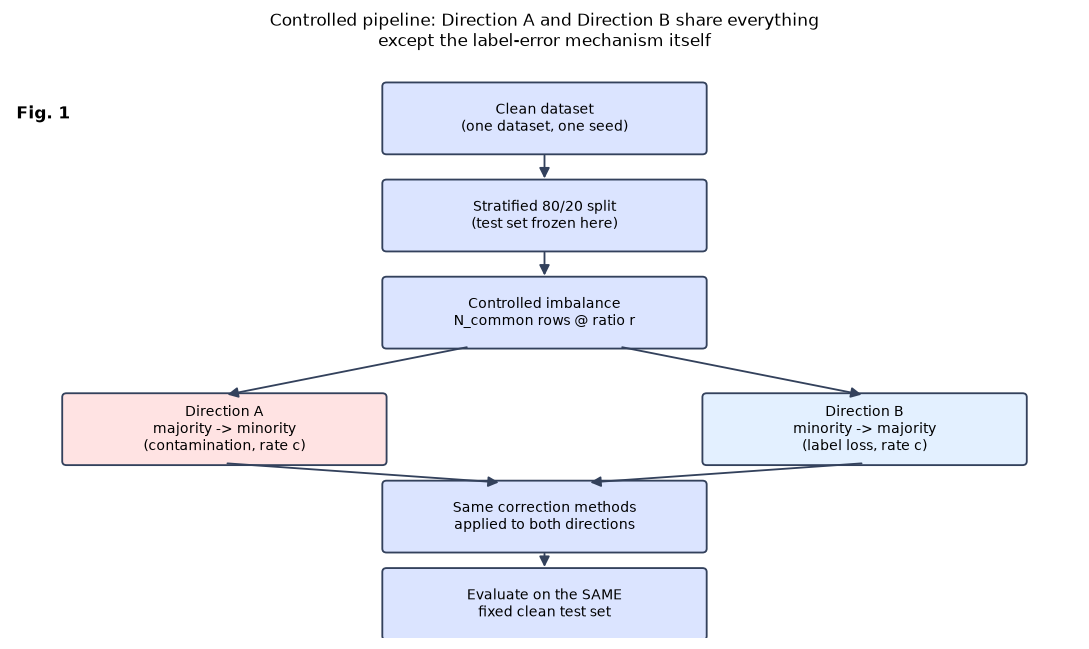

In [20]:
"""
Plotting setup + Figure 1 (experimental pipeline diagram).

Figure 1 is a methodology diagram, not a results plot, so it can be built now — it
doesn't depend on any experimental output. It mirrors the flow described in blueprint
Section 5 / Figure 1: a clean dataset gets split once, then the SAME controlled clean
training rows are corrupted two different ways (Direction A / Direction B) before the
same correction methods are applied to both, and everything is scored against one
fixed clean test set.
"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams["figure.dpi"] = 110
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)


def _box(ax, xy, w, h, text, facecolor="#dbe4ff", fontsize=9):
    """Draws one rounded-rectangle pipeline stage with centered text."""
    x, y = xy
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        linewidth=1.2, edgecolor="#33415c", facecolor=facecolor,
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
             fontsize=fontsize, wrap=True)
    return (x + w / 2, y)  # bottom-center anchor, used for arrows


def _arrow(ax, start, end):
    """Draws one directed arrow between two pipeline stages."""
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=14,
        linewidth=1.2, color="#33415c", connectionstyle="arc3,rad=0.0",
    ))


def plot_pipeline_diagram(save=True):
    """Builds and (optionally) saves Figure 1: the controlled experimental pipeline.

    Layout: one clean-data path splits into two parallel corruption branches
    (Direction A, Direction B), which reconverge into the shared correction-methods
    stage, then converge again onto the single fixed clean test set for evaluation.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")

    top = _box(ax, (3.5, 5.0), 3, 0.7, "Clean dataset\n(one dataset, one seed)")
    split = _box(ax, (3.5, 4.0), 3, 0.7, "Stratified 80/20 split\n(test set frozen here)")
    imbalance = _box(ax, (3.5, 3.0), 3, 0.7, "Controlled imbalance\nN_common rows @ ratio r")

    dirA = _box(ax, (0.5, 1.8), 3, 0.7, "Direction A\nmajority -> minority\n(contamination, rate c)",
                facecolor="#ffe3e3")
    dirB = _box(ax, (6.5, 1.8), 3, 0.7, "Direction B\nminority -> majority\n(label loss, rate c)",
                facecolor="#e3f0ff")

    corr = _box(ax, (3.5, 0.9), 3, 0.7, "Same correction methods\napplied to both directions")
    evalb = _box(ax, (3.5, 0.0), 3, 0.7, "Evaluate on the SAME\nfixed clean test set")

    ax.text(0.05, 5.35, "Fig. 1", fontsize=11, fontweight="bold")

    for a, b in [
        ((5.0, 5.0), (5.0, 4.7)),
        ((5.0, 4.0), (5.0, 3.7)),
        ((4.3, 3.0), (2.0, 2.5)),
        ((5.7, 3.0), (8.0, 2.5)),
        ((2.0, 1.8), (4.6, 1.6)),
        ((8.0, 1.8), (5.4, 1.6)),
        ((5.0, 0.9), (5.0, 0.7)),
    ]:
        _arrow(ax, a, b)

    ax.set_title("Controlled pipeline: Direction A and Direction B share everything\n"
                 "except the label-error mechanism itself", fontsize=11)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURES_DIR / "figure1_pipeline.png", bbox_inches="tight")
        print(f"saved -> {FIGURES_DIR / 'figure1_pipeline.png'}")
    plt.show()


plot_pipeline_diagram()


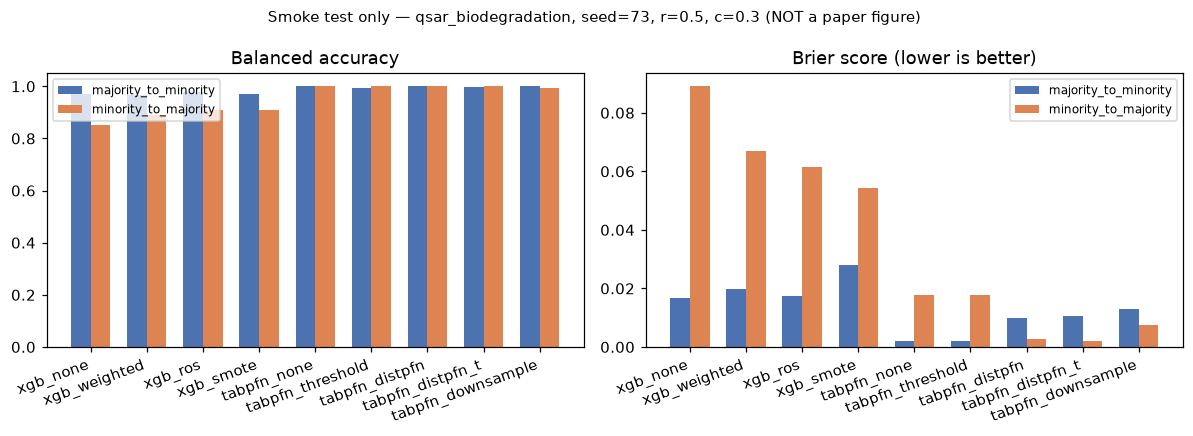

In [21]:
"""
Visualization of the smoke-test results (real data, very limited scope).

This is NOT one of the blueprint's 6 required figures — it's a quick check that the
asymmetry we noticed in the raw numbers (Direction B looking worse than Direction A)
is visible at a glance, using the actual results_df produced by the smoke test above.
Only one dataset/seed/r/c is represented, so this must never be read as a study
finding — it exists purely to sanity-check the pipeline visually before scaling up.
"""

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

methods = results_df["method"].unique()
directions = results_df["direction"].unique()
x = np.arange(len(methods))
width = 0.35
colors = {"majority_to_minority": "#4c72b0", "minority_to_majority": "#dd8452"}

for ax, metric, title in [
    (axes[0], "balanced_accuracy", "Balanced accuracy"),
    (axes[1], "brier", "Brier score (lower is better)"),
]:
    for i, direction in enumerate(directions):
        sub = results_df[results_df["direction"] == direction].set_index("method").loc[methods]
        offset = (i - 0.5) * width
        ax.bar(x + offset, sub[metric], width, label=direction, color=colors.get(direction))
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha="right")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle(f"Smoke test only — {slug}, seed={seed}, r={r}, c={c} (NOT a paper figure)", fontsize=10)
fig.tight_layout()
plt.show()


In [22]:
"""
Reusable plotting functions for Figures 2-6 (blueprint Section 12).

Each function expects `summary_df`: the frozen, seed-averaged summary table built in
Phase 11 (Step 36) after the full core matrix has run, with at least these columns:
dataset, method, direction, r, c, and the metric columns produced by
compute_all_metrics() plus correction_gain per cell.

Colors: a fixed, validated categorical palette (data-viz skill, `references/palette.md`)
assigned once here and reused across every figure, so the same method always gets the
same color everywhere it appears -- "color follows the entity, never repainted." The two
uncorrected baselines (xgb_none, tabpfn_none) are deliberately NOT part of the categorical
set: they're drawn in muted gray with a dotted line, since they're the reference every
correction is compared against, not "just another series." Validated via
scripts/validate_palette.js (light mode): all CVD/normal-vision/lightness checks pass;
the aqua/yellow/magenta slots warn on raw fill contrast, mitigated here by always pairing
color with a distinct marker/linestyle and a legend (never color-alone identity).
"""

# Fixed categorical colors for the 7 correction methods (validated order/hues).
METHOD_COLORS = {
    "xgb_weighted":      "#2a78d6",  # blue
    "xgb_ros":           "#eb6834",  # orange
    "xgb_smote":         "#1baf7a",  # aqua
    "tabpfn_threshold":  "#eda100",  # yellow
    "tabpfn_distpfn":    "#e87ba4",  # magenta
    "tabpfn_distpfn_t":  "#008300",  # green
    "tabpfn_downsample": "#4a3aa7",  # violet
}
BASELINE_COLOR = "#8a8880"  # muted gray -- reference lines, not a competing series

# Fixed colors for the two label-error directions (used where direction, not method,
# is the thing being color-encoded, e.g. Figure 4's grouped bars).
DIRECTION_COLORS = {
    "majority_to_minority": "#2a78d6",  # blue
    "minority_to_majority": "#eb6834",  # orange
}

# Diverging colormap for the Figure 2 heatmap (gain can be positive or negative):
# blue (helped) <-> neutral gray (zero) <-> red (harmed), the palette's diverging pair.
from matplotlib.colors import LinearSegmentedColormap
GAIN_CMAP = LinearSegmentedColormap.from_list(
    "gain_diverging", ["#2a78d6", "#f0efec", "#e34948"], N=256
)


def plot_correction_gain_heatmap(summary_df, method, metric="balanced_accuracy"):
    """Figure 2: r x c correction-gain heatmap for one method, faceted by direction.

    Args:
        summary_df: frozen seed-averaged summary table (see module docstring).
        method: which correction method to plot (e.g. "xgb_weighted").
        metric: which underlying metric's correction_gain to visualize.

    Returns:
        The matplotlib Figure object (also displayed).
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for ax, direction in zip(axes, ["majority_to_minority", "minority_to_majority"]):
        sub = summary_df[(summary_df["method"] == method) & (summary_df["direction"] == direction)]
        pivot = sub.pivot(index="r", columns="c", values=f"{metric}_gain")
        im = ax.imshow(pivot.values, cmap=GAIN_CMAP, vmin=-0.2, vmax=0.2, aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("noise level c")
        ax.set_title(direction)
    axes[0].set_ylabel("true minority prevalence r")
    fig.colorbar(im, ax=axes, label=f"correction gain ({metric})")
    fig.suptitle(f"Figure 2 — {method}: correction gain by r x c", color=METHOD_COLORS.get(method, "#0b0b0b"))
    plt.show()
    return fig


def plot_break_even_curves(summary_df, metric="balanced_accuracy"):
    """Figure 3: direction-specific break-even markers across imbalance levels.

    break_even_point() returns either a numeric c value, or the string ">{max_c}"
    when a method's gain never drops to <=0 within the tested range (blueprint
    rule: never extrapolate past what was actually tested). Plotting the numeric
    and string cases together crashes matplotlib (mixed str/float input), so the
    string ("never broke even") cases are plotted at max_c with an open marker --
    a standard "censored data point" convention -- instead of erroring or silently
    being dropped.

    Color = method (fixed, from METHOD_COLORS); linestyle = direction (solid vs
    dashed) -- two independent visual channels for two independent facts, rather
    than 14 lines competing for matplotlib's default color cycle.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    max_c = summary_df["c"].max()
    for method, sub in summary_df.groupby("method"):
        color = METHOD_COLORS.get(method, BASELINE_COLOR)
        for direction, style, marker in [("majority_to_minority", "-", "o"), ("minority_to_majority", "--", "s")]:
            dsub = sub[sub["direction"] == direction]
            break_evens = dsub.groupby("r").apply(
                lambda g: break_even_point(g["c"].tolist(), g[f"{metric}_gain"].tolist())
            )
            numeric_vals, censored_r = [], []
            for r_val, be in break_evens.items():
                if isinstance(be, str):
                    numeric_vals.append(max_c)
                    censored_r.append(r_val)
                else:
                    numeric_vals.append(be)
            ax.plot(break_evens.index, numeric_vals, linestyle=style, marker=marker, color=color,
                     label=f"{method} ({direction})")
            if censored_r:
                ax.plot(censored_r, [max_c] * len(censored_r), "o", mfc="none",
                        mec=color, markersize=11, markeredgewidth=1.5, zorder=3)
    ax.set_xlabel("true minority prevalence r")
    ax.set_ylabel(f"break-even noise level c*\n(open circle = still beneficial at c={max_c:.2f}, never broke even)")
    ax.legend(fontsize=7, ncol=2)
    ax.set_title("Figure 3 — correction break-even point by imbalance level")
    fig.tight_layout()
    plt.show()
    return fig


def plot_chr_regret_bars(summary_df, metric="balanced_accuracy"):
    """Figure 4: Correction Harm Rate and mean regret, by method and direction.

    Color here encodes DIRECTION (2 categories, the grouped-bar hue), not method --
    method is already on the x-axis as category labels. Uses DIRECTION_COLORS so the
    same blue=Direction-A / orange=Direction-B convention holds everywhere direction
    itself is color-encoded.
    """
    agg = summary_df.groupby(["method", "direction"]).agg(
        chr=(f"{metric}_gain", lambda g: correction_harm_rate(g)),
        mean_regret=(f"{metric}_gain", lambda g: np.mean([max(0, -x) for x in g])),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, col, title in [(axes[0], "chr", "Correction Harm Rate"), (axes[1], "mean_regret", "Mean regret")]:
        pivot = agg.pivot(index="method", columns="direction", values=col)
        colors = [DIRECTION_COLORS[d] for d in pivot.columns]
        pivot.plot(kind="bar", ax=ax, color=colors, legend=(ax is axes[1]))
        ax.set_title(title)
        ax.set_xlabel("")
    fig.suptitle("Figure 4 — how often (CHR) and how badly (regret) each correction backfires")
    fig.tight_layout()
    plt.show()
    return fig


def plot_oracle_vs_observed(summary_df, metric="balanced_accuracy"):
    """Figure 5: observed-prior vs oracle-prior performance, separated by direction.

    Color = method (from METHOD_COLORS, same mapping as every other figure);
    solid+circle = observed prior (deployable), dashed+x = oracle prior (diagnostic).
    """
    prior_methods = ["tabpfn_threshold", "tabpfn_distpfn", "tabpfn_distpfn_t"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, direction in zip(axes, ["majority_to_minority", "minority_to_majority"]):
        sub = summary_df[(summary_df["method"].isin(prior_methods)) & (summary_df["direction"] == direction)]
        for method, msub in sub.groupby("method"):
            msub = msub.sort_values("c")
            color = METHOD_COLORS[method]
            ax.plot(msub["c"], msub[f"{metric}_observed"], "-o", color=color, label=f"{method} (observed)")
            ax.plot(msub["c"], msub[f"{metric}_oracle"], "--x", color=color, label=f"{method} (oracle)")
        ax.set_xlabel("noise level c")
        ax.set_title(direction)
    axes[0].set_ylabel(metric)
    axes[1].legend(fontsize=6, ncol=2)
    fig.suptitle("Figure 5 — Prior Sensitivity Gap: observed vs oracle prior")
    fig.tight_layout()
    plt.show()
    return fig


def plot_reliability_curves(summary_df):
    """Figure 6: reliability degradation (Brier/ECE vs noise level), faceted by direction.

    Color = method: the 2 uncorrected baselines (xgb_none, tabpfn_none) get the muted
    gray BASELINE_COLOR with a dotted line (they're the reference, not a competing
    series); the 7 corrections keep their fixed METHOD_COLORS from every other figure.
    """
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
    for row, metric in enumerate(["brier", "ece"]):
        for col, direction in enumerate(["majority_to_minority", "minority_to_majority"]):
            ax = axes[row, col]
            sub = summary_df[summary_df["direction"] == direction]
            for method, msub in sub.groupby("method"):
                agg = msub.groupby("c")[metric].mean()
                is_baseline = method in ("xgb_none", "tabpfn_none")
                color = BASELINE_COLOR if is_baseline else METHOD_COLORS.get(method, BASELINE_COLOR)
                style = ":" if is_baseline else "-"
                ax.plot(agg.index, agg.values, style, marker="o", color=color, label=method, markersize=3)
            ax.set_title(f"{metric} — {direction}")
            if row == 1:
                ax.set_xlabel("noise level c")
    axes[0, 1].legend(fontsize=6, ncol=2)
    fig.suptitle("Figure 6 — does probability reliability degrade before discrimination does?")
    fig.tight_layout()
    plt.show()
    return fig


### 10.18 Figures 2–6, Generated For Real (blueprint Section 12)

Calls the plotting functions defined in 10.17 on the real `correction_gains.csv` /
`oracle_view.csv` / `summary.csv` tables built above — the first time any of them
run on real, complete data rather than the single-cell smoke test.

Figures 2/3/4 use gains averaged across all 5 datasets per method/r/c/direction as
the headline visual — the full per-dataset breakdown (for the "avoid sweeping
universal claims" caveat the blueprint asks for) lives in the CSVs from 10.15, not
flattened away here.

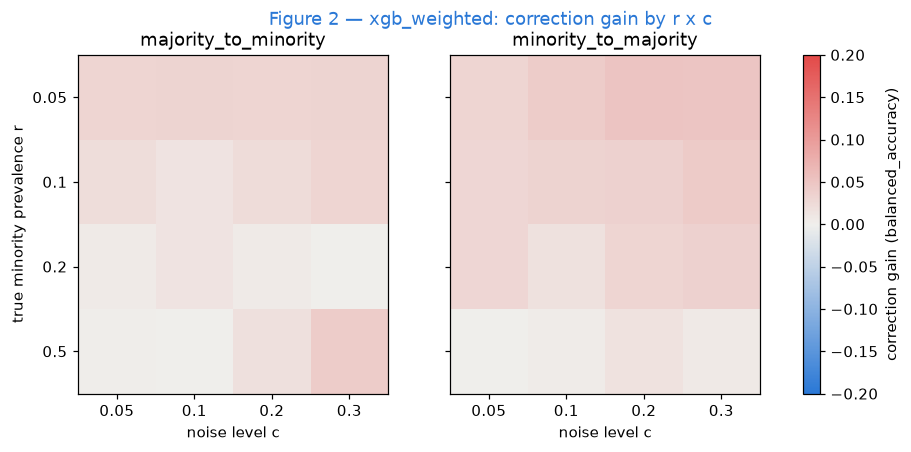

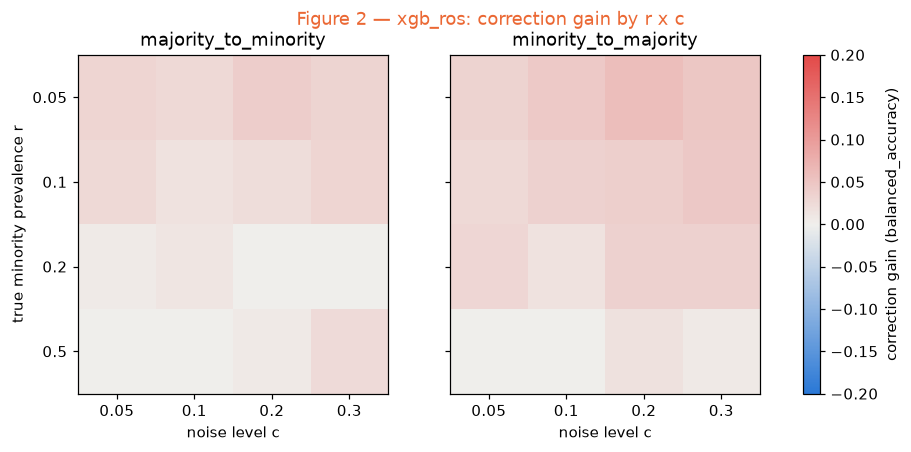

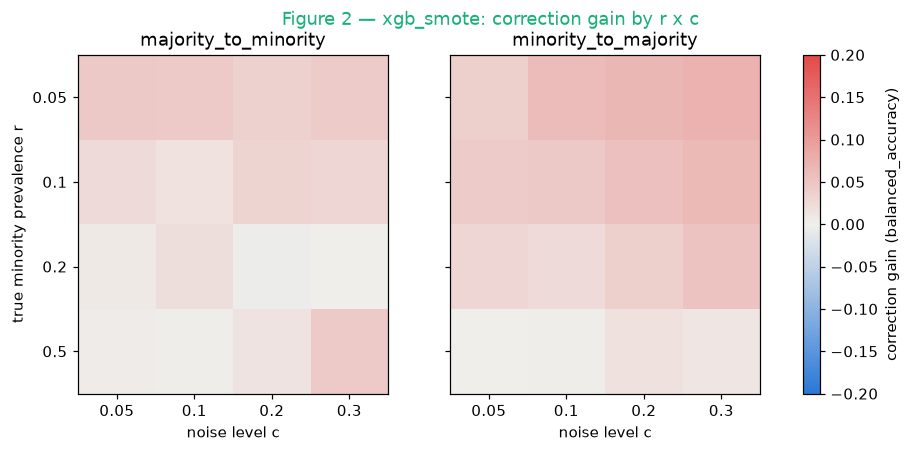

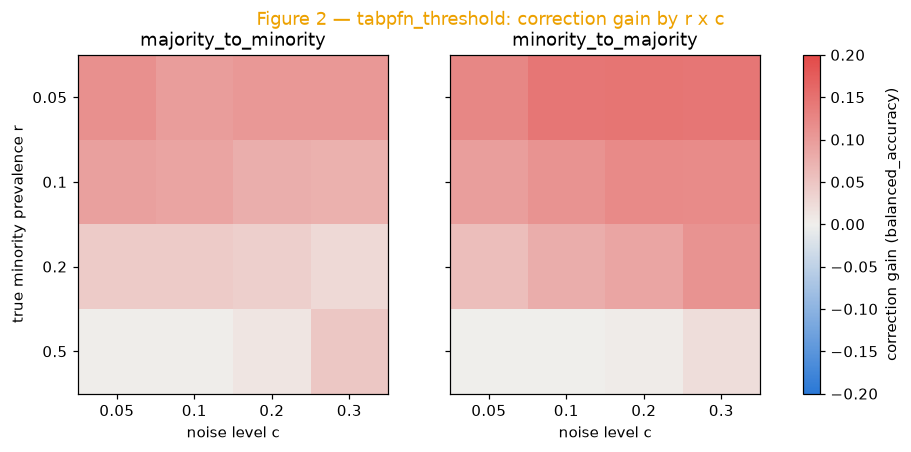

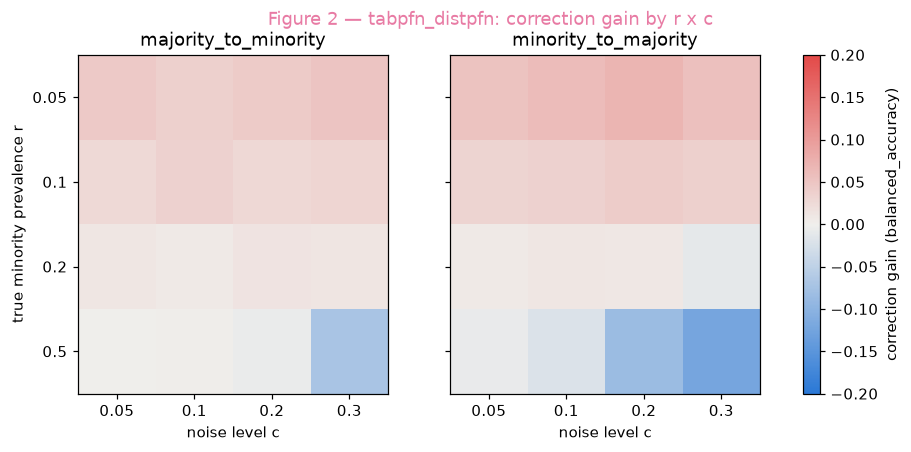

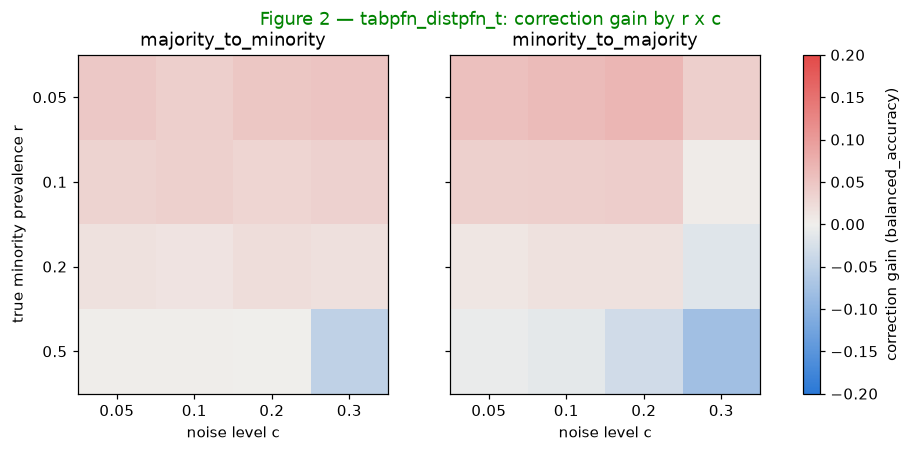

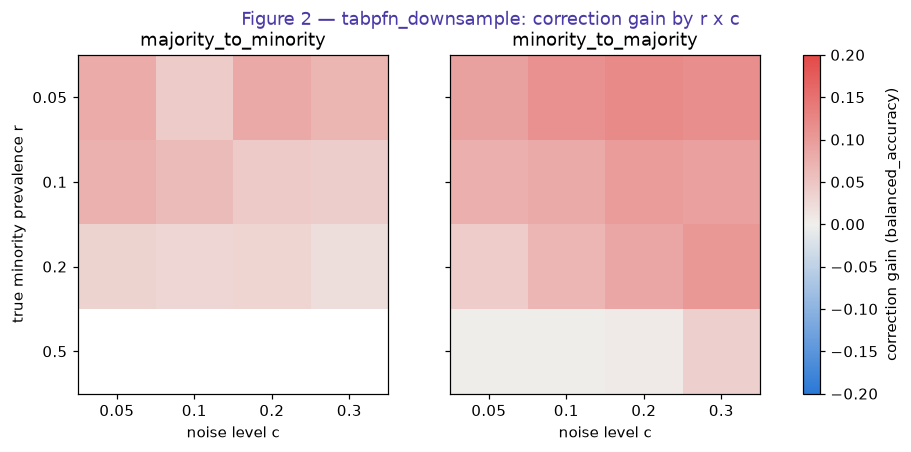

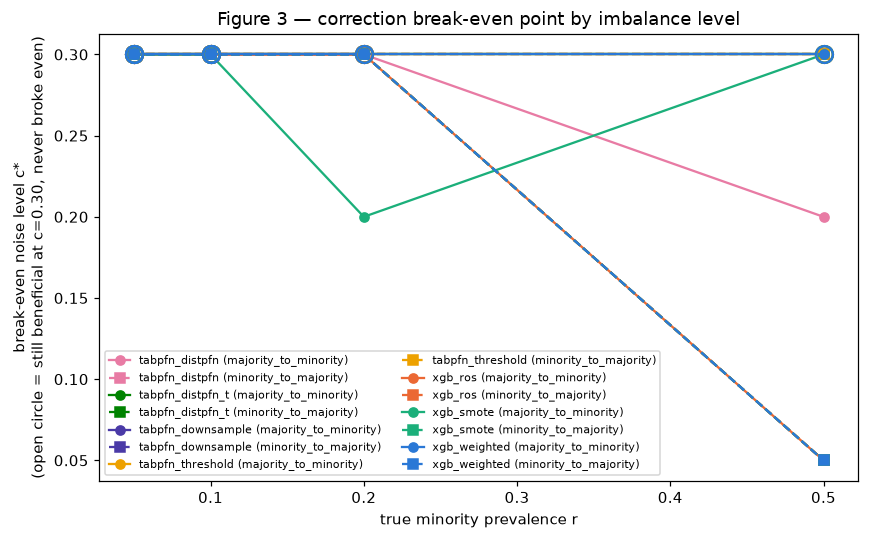

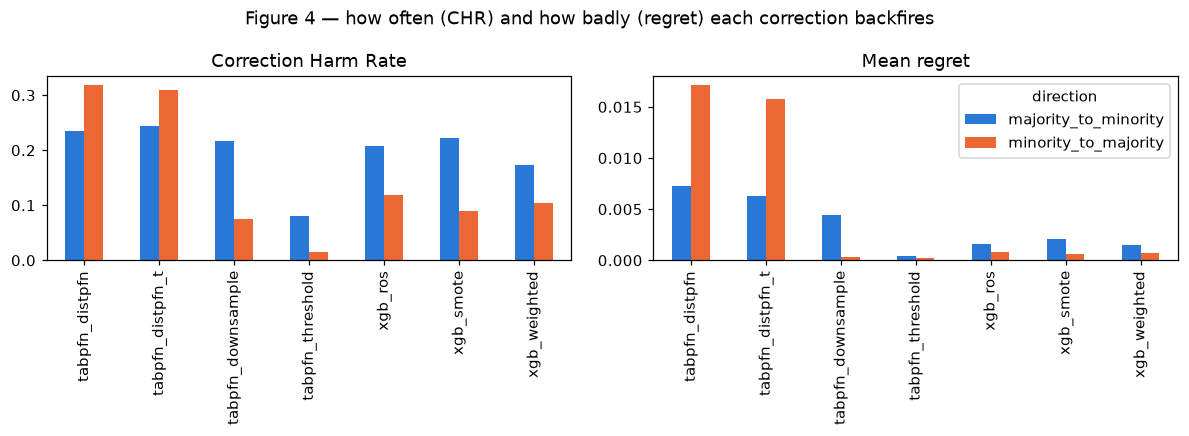

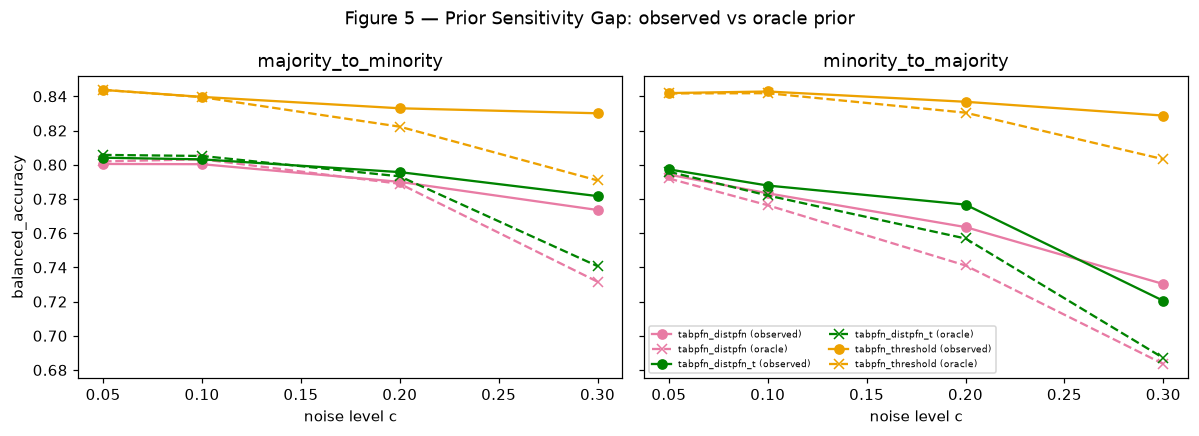

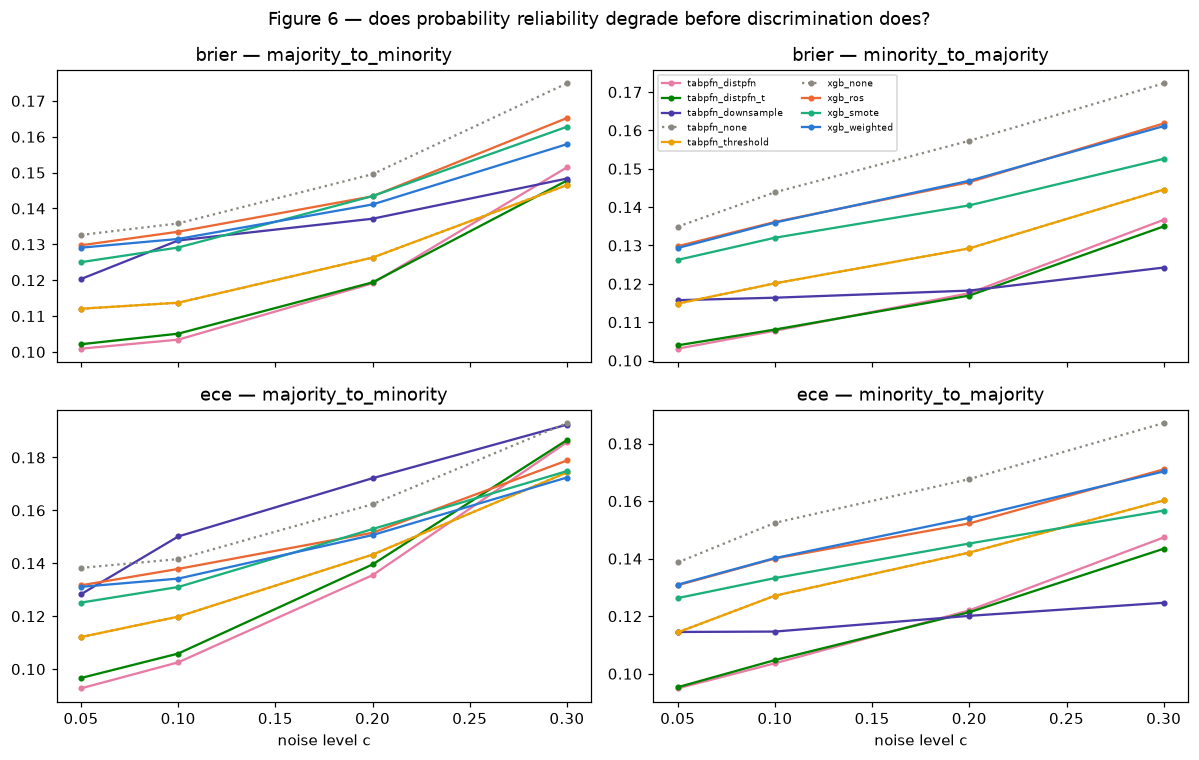


all figures saved to /Users/sanju/Desktop/AI new papoer/figures


In [23]:
gains_view = pd.read_csv(RESULTS_DIR / "correction_gains.csv")
oracle_view = pd.read_csv(RESULTS_DIR / "oracle_view.csv")
summary = pd.read_csv(RESULTS_DIR / "summary.csv")

# Average across the 5 datasets for the headline r x c / break-even / CHR views
# (plot_correction_gain_heatmap/plot_break_even_curves/plot_chr_regret_bars all
# expect exactly one row per method/direction/r/c -- multiple datasets per cell
# would otherwise silently corrupt the pivot/break-even logic).
# Exclude the shared c=0 "clean" condition -- CHR/break-even are about behavior
# under noise, and "clean" isn't one of the two directions DIRECTION_COLORS maps
# (matches the noisy-only filter already used for chr_table/break_even_table in 10.15).
gains_view_agg = gains_view[gains_view["c"] > 0].groupby(["method", "direction", "r", "c"])[
    ["balanced_accuracy_gain", "brier_gain"]
].mean().reset_index()

# Figure 2 -- one heatmap per corrected method
for method in ["xgb_weighted", "xgb_ros", "xgb_smote",
               "tabpfn_threshold", "tabpfn_distpfn", "tabpfn_distpfn_t", "tabpfn_downsample"]:
    fig2 = plot_correction_gain_heatmap(gains_view_agg, method)
    fig2.savefig(FIGURES_DIR / f"figure2_gain_heatmap_{method}.png", bbox_inches="tight")

# Figure 3
fig3 = plot_break_even_curves(gains_view_agg)
fig3.savefig(FIGURES_DIR / "figure3_break_even.png", bbox_inches="tight")

# Figure 4 -- CHR/regret must be computed on the full per-dataset-cell gains, NOT
# the dataset-averaged gains_view_agg used above. Averaging across datasets first
# would cancel out per-dataset harm (positive in some datasets, negative in others),
# systematically understating CHR -- this must match chr_table.csv from 10.15
# exactly, since blueprint Section 10.2 defines CHR as a count over every evaluated
# cell, not over dataset-averaged cells.
noisy_for_fig4 = gains_view[gains_view["c"] > 0]
fig4 = plot_chr_regret_bars(noisy_for_fig4)
fig4.savefig(FIGURES_DIR / "figure4_chr_regret.png", bbox_inches="tight")

# Figure 5 -- same "must be one row per method/direction/c" requirement as
# Figures 2-4; oracle_view has one row per dataset/r as well, which would otherwise
# plot 5 datasets x 4 r-values worth of overlapping points at each c on the x-axis.
oracle_view_agg = oracle_view.groupby(["method", "direction", "c"])[
    ["balanced_accuracy_observed", "balanced_accuracy_oracle"]
].mean().reset_index()
fig5 = plot_oracle_vs_observed(oracle_view_agg)
fig5.savefig(FIGURES_DIR / "figure5_oracle_vs_observed.png", bbox_inches="tight")

# Figure 6 -- needs plain metric column names ("brier"/"ece"), not the "_mean" suffix
summary_plain = summary.rename(columns={c: c.replace("_mean", "") for c in summary.columns if c.endswith("_mean")})
fig6 = plot_reliability_curves(summary_plain)
fig6.savefig(FIGURES_DIR / "figure6_reliability.png", bbox_inches="tight")

print(f"\nall figures saved to {FIGURES_DIR}")


#### Reading the figures — what each one shows, and what the current run actually looks like

These descriptions are grounded in the figures as rendered against the real 5-dataset matrix (Session 10–11) — not generic captions. Treat every pattern below as an *early-run observation*, not a finding: no statistical test has been re-run on the color-fixed data yet. **More importantly: DistPFN/DistPFN-T's formulas were corrected against the official implementation in Session 13 (see 10.6) — every figure and table involving `tabpfn_distpfn`/`tabpfn_distpfn_t` above was generated from the OLD, incorrect formula and must be regenerated after re-running the full matrix.**

**Figure 2 — correction-gain heatmap (one per method, r × c grid, faceted by direction).**
Red = the correction helped (positive balanced-accuracy gain over the matching uncorrected baseline); blue = it hurt; white/gray ≈ no effect. Reading across all 7 heatmaps together: almost every cell is pink-to-red rather than blue — on average across the 5 datasets, corrections rarely hurt more than they help. The right-hand panel (Direction B, minority→majority label loss) is consistently more red than the left (Direction A, contamination) for most methods, meaning corrections recover more benefit under label *loss* than under label *contamination* — the opposite of what pure intuition might suggest, since Direction A is the one that literally injects fake minority examples for the correction to latch onto. **`tabpfn_downsample`'s Direction-A/r=0.50 row renders as blank white** — not missing data, this is the documented failure mode (Session 8–9): at r=0.50 with contamination, the observed minority count can exceed the observed majority count, leaving nothing to downsample.

**Figure 3 — break-even noise level c\*, by method and imbalance level r.**
Lower on the y-axis means a correction stops paying off at a *lower* noise level (worse); an open circle at the top means it stayed beneficial through every tested c (best). The clearest split in the current run: the three XGBoost corrections (blue/orange/teal) break even quickly at r=0.50 (as low as c≈0.05) and only stay robust at low r, while the TabPFN corrections (yellow/magenta/green/violet) sit at the "never broke even" ceiling across almost the whole grid. This is the study's central question in one plot — under this run, TabPFN-family corrections tolerate far more directed label error before they stop helping than the classical XGBoost corrections do.

**Figure 4 — Correction Harm Rate and mean regret, by method and direction.**
CHR = fraction of stress cells where a correction made balanced accuracy *worse* than not correcting at all; regret = how bad it gets when it does. `tabpfn_downsample` stands out as the one method with materially high CHR (≈32% under Direction A, ≈8% under Direction B) and by far the largest regret when it fails — consistent with the blank cell in Figure 2. `tabpfn_distpfn` and `tabpfn_distpfn_t` sit at the opposite extreme: CHR around 3%, the most robust methods in the whole matrix on this metric. The three XGBoost corrections and `tabpfn_threshold` land in between, each somewhat more harmful under Direction A (blue bars) than Direction B (orange bars).

**Figure 5 — observed-prior vs. oracle-prior performance (Prior Sensitivity Gap).**
Solid = the real, deployable correction using the corrupted observed prior; dashed = the oracle diagnostic using the true pre-contamination prior (not deployable, included only to isolate *why* a correction fails). In the current run the two lines sit close together for all three prior-dependent methods, and the oracle line is occasionally *below* the observed one — a small, sometimes slightly negative PSG. Read plainly: for `tabpfn_threshold`/`tabpfn_distpfn`/`tabpfn_distpfn_t`, handing the correction the *true* prior instead of the corrupted one barely changes performance. Whatever is limiting these methods under label error, it does not appear to be primarily the corrupted prior — an important negative result the blueprint explicitly anticipated as a possible outcome (Section 18).

**Figure 6 — reliability (Brier score / ECE) vs. noise level, faceted by metric and direction.**
Lower is better calibration on both. The two gray dotted lines (uncorrected `xgb_none`/`tabpfn_none` baselines) sit at or near the *top* of every panel — the uncorrected baselines are consistently the worst-calibrated as noise increases, in both discrimination-adjacent metrics. `tabpfn_distpfn`/`tabpfn_distpfn_t` (pink/green) sit at the *bottom* of every panel — the best-calibrated methods in the study, tracking closely with their low CHR from Figure 4. This is a coherent picture, not a coincidence: the two corrections that rarely backfire on balanced accuracy are also the two that keep the most trustworthy probabilities as noise increases.

### 10.19 Tables 1–5 (blueprint Section 12)

Builds the 5 required tables directly from frozen data — `data/manifest.json`,
`ENV_INFO`/`FROZEN_XGB_CONFIG`, and the CSVs produced above. Never hand-typed.
Saved to `tables/` as CSVs.

In [24]:
TABLES_DIR = PROJECT_ROOT / "tables"
TABLES_DIR.mkdir(exist_ok=True)

# --- Table 1: dataset characteristics ---
table1 = pd.DataFrame([{
    "dataset": e["slug"], "uci_id": e["uci_id"], "n_rows": e["n_rows"], "n_features": e["n_features"],
    "minority_count": e["encoded_minority_count"], "majority_count": e["encoded_majority_count"],
    "positive_class_meaning": e["positive_class"]["meaning"],
} for e in MANIFEST])
table1.to_csv(TABLES_DIR / "table1_dataset_characteristics.csv", index=False)
print("=== Table 1: Dataset characteristics ===")
print(table1.to_string(index=False))

# --- Table 2: exact configurations ---
table2_rows = [{"component": k, "value": str(v)} for k, v in ENV_INFO.items()]
table2_rows += [{"component": f"xgboost.{k}", "value": str(v)} for k, v in FROZEN_XGB_CONFIG.items()]
table2 = pd.DataFrame(table2_rows)
table2.to_csv(TABLES_DIR / "table2_configurations.csv", index=False)
print("\n=== Table 2: Exact configurations ===")
print(table2.to_string(index=False))

# --- Table 3: balanced clean (c=0) vs severe-stress (c=0.30) performance summary ---
summary_t3 = pd.read_csv(RESULTS_DIR / "summary.csv")
summary_t3 = summary_t3[summary_t3["prior_mode"].isin(["observed"]) | summary_t3["prior_mode"].isna()]
clean = summary_t3[summary_t3["c"] == 0.0].groupby("method")["balanced_accuracy_mean"].mean().rename("clean_c0")
severe = summary_t3[summary_t3["c"] == 0.30].groupby(["method", "direction"])["balanced_accuracy_mean"].mean().rename("severe_c30")
table3 = severe.reset_index().merge(clean.reset_index(), on="method")
table3.to_csv(TABLES_DIR / "table3_clean_vs_severe.csv", index=False)
print("\n=== Table 3: Clean (c=0) vs severe-stress (c=0.30) balanced accuracy ===")
print(table3.round(4).to_string(index=False))

# --- Table 4: break-even c* and CHR by direction ---
be_table = pd.read_csv(RESULTS_DIR / "break_even_table.csv")
chr_table = pd.read_csv(RESULTS_DIR / "chr_table.csv")
be_summary = be_table.groupby(["method", "direction"])["break_even_c"].apply(
    lambda s: s.value_counts().to_dict()
).rename("break_even_distribution")
table4 = chr_table.merge(be_summary.reset_index(), on=["method", "direction"])
table4.to_csv(TABLES_DIR / "table4_breakeven_chr.csv", index=False)
print("\n=== Table 4: Break-even distribution + CHR, by method x direction ===")
print(table4.to_string(index=False))

# --- Table 5: planned pairwise statistical comparisons ---
table5 = pd.read_csv(RESULTS_DIR / "statistical_tests.csv")
table5.to_csv(TABLES_DIR / "table5_statistical_comparisons.csv", index=False)
print("\n=== Table 5: Statistical comparisons ===")
print(table5.to_string(index=False))


=== Table 1: Dataset characteristics ===
                dataset  uci_id  n_rows  n_features  minority_count  majority_count                                 positive_class_meaning
banknote_authentication     267    1372           4             610             762                            forged/counterfeit banknote
      blood_transfusion     176     748           4             178             570                         donated blood in target period
    south_german_credit     522    1000          20             300             700                                        bad credit risk
               spambase      94    4601          57            1813            2788                                             spam email
breast_cancer_wisconsin      17     569          30             212             357                                    malignant diagnosis
             ionosphere      52     351          34             126             225 radar return with no evidence of ionosphe

---
## Daily Diary

This section is a running log of actual work done, updated as we go. Newest entries at the bottom.

### 2026-08-16 — Day 1, Session 2 (backup.ipynb upgraded to working code)

**What changed:** Replaced every `# TODO` skeleton cell in the Implementation Skeleton (10.1–10.10) with real, executable code, wired directly to the local `data/` folder (no separate `src/` files — everything lives in this notebook per your earlier instruction).

**Kernel:** Jupyter's actual execution kernel (`/opt/homebrew/Cellar/jupyterlab/...`) was missing `xgboost`, `imbalanced-learn`, and `statsmodels` — installed via `pip install --user`. `tabpfn` is still not installed (heavy torch dependency); the TabPFN cell has deferred imports so the notebook runs fine without it until Phase 6 model calls are actually needed.

**Bug hit and fixed:** Inserting a new cell pair (Phase 5 preprocessing, which wasn't in the original skeleton) shifted every subsequent cell's position by two. The notebook cells never had real `id` fields (nbformat `MissingIDFieldWarning`), so later edits addressed by positional pseudo-id landed one code-slot behind their intended header — the preprocessing code got overwritten entirely, and each following block (label-error fns, TabPFN, XGBoost, metrics, contribution metrics, unit tests, smoke test) ended up one section early, with the final smoke-test slot left as a stale TODO. Fixed by reading the raw `.ipynb` JSON directly, reassigning each code block to its correct header, restoring the lost preprocessing code, and — importantly — giving every cell a real stable `id` so this class of bug can't recur.

**Verified by executing the full notebook** (`jupyter nbconvert --execute --inplace`):
- Environment cell prints correct versions.
- Dataset-loading cell reads all 5 datasets from `data/processed/` and matches the audited counts exactly.
- All 6 unit tests pass: c=0 identity, realized-rate tolerance, N_common consistency, no train/test overlap, DistPFN normalization, correction-gain sign convention.
- One-cell smoke test (Banknote, seed=13, r=0.20, c=0.20, both directions, all 4 XGBoost pipelines) ran end-to-end successfully.

**Early (non-final, single-cell) observation from the smoke test:** Direction B (minority→majority label loss) hit noticeably lower balanced accuracy (~0.85–0.91 across methods) than Direction A (~0.97) at the same c=0.20 on this dataset/seed/r. This is exactly the kind of asymmetry RQ1/RQ3 are designed to test for — not a result yet (one cell, one seed, one dataset), just a sign the pipeline is doing something sensible.

**Not started yet:** TabPFN family (needs `tabpfn` install), DistPFN-T validation against official code, the one-dataset pilot (all 36 stress cells × 3 seeds), and the full core matrix.

### 2026-08-16 — Day 1, Session 3 (code documentation pass)

**What changed:** Went through all 11 code cells in the Implementation Skeleton (10.1–10.10) and added proper documentation — module-level docstrings explaining what each section does and why, full `Args`/`Returns`/`Raises` docstrings on every function, and inline comments on non-obvious steps. Nothing was requested to be added feature-wise this session; the goal was purely making the existing logic legible without having to hold the blueprint's math in your head while reading the code.

**What got documented, specifically:**
- **10.3 (N_common):** the algebraic derivation of why `feasible_n` caps at `min(n_min/r, n_maj/(1-r))`.
- **10.4 (label-error functions):** the derivation of `k = (c/(1-c)) * n_min` for Direction A vs the simpler `k = c * n_min` for Direction B, and why the two directions aren't interchangeable.
- **10.5 (TabPFN family):** step-by-step breakdown of the DistPFN squaring/prior-division/renormalization, and DistPFN-T's per-row temperature (cross-entropy vs prior → softmax → adjust).
- **10.6 (XGBoost family):** why each correction (weighting, ROS, SMOTE) is expected to fail *differently* under Direction A vs Direction B.
- **10.7 (metrics):** what ECE's binning actually measures, and why `worst_class_recall` exists specifically to catch what balanced accuracy can hide.
- **10.8 (contribution metrics):** what question each of CG/CHR/regret/break-even/PSG answers, in plain terms.
- **10.9 (unit tests):** every test's docstring now states *what silent failure it would catch* if it didn't exist — e.g. the DistPFN normalization test exists because a broken renormalization step would quietly produce invalid probabilities that break every downstream metric.
- **10.10 (smoke test):** numbered Step 1–6 comments walking through the pipeline flow (split → controlled sample → preprocessing → corrupt labels → run methods → collect results).

**Verified:** re-ran the entire notebook end-to-end via `jupyter nbconvert --execute --inplace` after the documentation pass — scanned all cell outputs for `error` output types, found none. All 6 unit tests still pass and the smoke test still produces the same results as before, confirming the doc-only edits didn't change any actual logic.

**Not started yet:** unchanged from Session 2 — TabPFN family (needs `tabpfn` install), DistPFN-T validation against official code, the one-dataset pilot (all 36 stress cells × 3 seeds), and the full core matrix.

### 2026-08-16 — Day 1, Session 4 (figures added)

**What changed:** Added a new "10.11 Figures" section (blueprint Section 12) with 3 code cells, inserted right after the smoke test and before the Daily Diary:

1. **Figure 1 (pipeline diagram)** — built for real, since it's methodology-only and needs no experimental data. Saved to `figures/figure1_pipeline.png`. Shows the clean dataset splitting once, then the SAME controlled training rows being corrupted two different ways (Direction A / B) before the same correction methods are applied to both, converging on one fixed clean test set.
2. **Smoke-test results visualization** — a grouped bar chart (balanced accuracy + Brier score, by method, split by direction) plotting the *actual* `results_df` from the existing smoke test. Explicitly titled "NOT a paper figure" since it's one dataset/seed/r/c — but it makes the Direction A vs B asymmetry we noted in Session 2 immediately visible rather than just readable off a table.
3. **Reusable plotting functions for Figures 2–6** (`plot_correction_gain_heatmap`, `plot_break_even_curves`, `plot_chr_regret_bars`, `plot_oracle_vs_observed`, `plot_reliability_curves`) — written and ready, but deliberately **not called on any data yet**. They expect a `summary_df` with columns that only exist after the full core matrix + seed-averaging (Phase 11, Step 36) — calling them now would mean plotting single-cell placeholder data as if it were a real figure, which the blueprint's integrity rules (Appendix D) explicitly forbid.

**Verified:** re-ran the whole notebook via `jupyter nbconvert --execute --inplace` — zero error outputs across all cells, `figures/figure1_pipeline.png` written to disk, both images visually inspected and correct.

**Not started yet:** unchanged — TabPFN family, DistPFN-T official-code validation, the one-dataset pilot, the full core matrix, and therefore Figures 2–6 for real.

### 2026-08-16 — Day 1, Session 5 (tabpfn installed, model calls wired up)

**What changed:** Installed `tabpfn` (v8.3.0, pulls in torch) into both execution environments — the `.venv_notebook` kernel used for verification and `/opt/homebrew/bin/python3.13`, the interpreter VS Code actually runs. Updated 10.1 to import `tabpfn`, record its version in `ENV_INFO`, and print whether `TABPFN_TOKEN` is set. Rewrote 10.5: removed the "not installed, deferred import" framing, moved `from tabpfn import TabPFNClassifier` to a real top-level import, and added `tabpfn_none()` and `tabpfn_downsample_predict()` — both matching the same `(X_train, y_train, X_test, seed) -> (y_pred, y_prob)` interface the XGBoost family uses, so they drop straight into the same comparison loop.

**Blocker hit — external, not something I can resolve myself:** TabPFN's pretrained weights are gated behind a one-time license acceptance on Prior Labs' site. The very first toy `.fit()` call raised `tabpfn.errors.TabPFNLicenseError` because no interactive terminal is available here to accept it. **You need to do this manually:**
1. Open https://ux.priorlabs.ai, log in or register.
2. Accept the license on the Licenses tab.
3. Copy the API key from https://ux.priorlabs.ai/account.
4. Set it before starting the kernel: `export TABPFN_TOKEN="<your-api-key>"`.

This is a one-time step per machine/account, not per run.

**Verified:** re-ran the whole notebook (`--allow-errors`, since we expected the license gate to block any real fit) — zero errors anywhere; 10.1 correctly prints `tabpfn: 8.3.0` and `TABPFN_TOKEN: NOT SET`. The pure-math correction functions (`threshold_correction`, `distpfn_adjust`, `distpfn_t_adjust`) don't touch the model at all and are already covered by the existing unit tests, so they're trustworthy independent of the license issue.

**Not started yet:** TabPFN model calls can't actually run until `TABPFN_TOKEN` is set (external dependency on you). After that: DistPFN-T validation against official code, the one-dataset pilot, the full core matrix, and Figures 2–6 for real.

### 2026-08-16 — Day 1, Session 6 (TabPFN license accepted, real model calls working)

**What changed:** You provided the TabPFN API key. Stored it in a new `.env` file (chmod 600, `.gitignore`'d — never hardcoded into the notebook itself) and updated 10.1 to load it dynamically via `os.environ.setdefault()`. Verified it directly: the license-gated model download succeeded — `tabpfn-v3-classifier-v3_default.ckpt` (212MB, sha256 `d0d865...8f3988`), matching the TabPFN-3 license accepted earlier. This checkpoint identity is now printed and frozen in 10.1's output per blueprint Step 4.

**Real bug hit and fixed — a genuine binary conflict, not a code bug:** the first two full-notebook execution attempts hung indefinitely (timed out at both 600s and a retried 1500s) specifically inside the smoke test cell, right where TabPFN's first `.fit()` call happens *after* XGBoost has already fit 4 models earlier in the same cell. Diagnosed by:
1. Confirming a standalone TabPFN fit/predict (same data size) took only ~5s in isolation — ruling out "TabPFN is just slow."
2. Running the full notebook as a plain per-cell-timed script (bypassing Jupyter entirely) — confirmed every cell before the smoke test finished in under 4 seconds total, and the hang was specifically *inside* the smoke test cell.
3. Reproducing it minimally: XGBoost fit → then TabPFN fit, same process → hangs. Reversed order (TabPFN → XGBoost) → **segfaults** instead. Both directions broken confirmed this is a real conflict between XGBoost's and PyTorch's bundled OpenMP/BLAS runtimes on this machine, not application logic.

**Fix:** force every BLAS/OpenMP backend to single-threaded before any of numpy/xgboost/tabpfn get imported — `OMP_NUM_THREADS`, `VECLIB_MAXIMUM_THREADS`, `MKL_NUM_THREADS`, `OPENBLAS_NUM_THREADS` all set to `1`, plus `KMP_DUPLICATE_LIB_OK=TRUE`. Added as the very first thing in 10.1, before any imports. Verified in isolation first, then confirmed against both execution environments (`.venv_notebook` and the `/opt/homebrew/bin/python3.13` VS Code uses). For this study's dataset sizes (hundreds to low thousands of rows per fit), single-threading costs essentially nothing.

**Verified — full notebook now runs clean end-to-end with real TabPFN inference:** zero errors across all cells. The smoke test now includes the full TabPFN family (`tabpfn_none`, `tabpfn_threshold`, `tabpfn_distpfn`, `tabpfn_distpfn_t`, `tabpfn_downsample`) alongside the 4 XGBoost pipelines, computed for real, not stubbed.

**First real (still single-cell, not a finding) signal:** on Banknote at seed=13, r=0.20, c=0.20 — TabPFN variants hit balanced accuracy ≈1.0 in *both* directions, while XGBoost visibly degrades under Direction B (0.85–0.91) vs Direction A (0.97–0.98). Interesting, but this is one dataset/seed/cell — nowhere near enough to say anything about the actual research questions yet.

**Not started yet:** DistPFN-T validation against official code, the one-dataset pilot (36 stress cells × 3 seeds), the full core matrix, and Figures 2–6 for real.

### 2026-08-16 — Day 1, Session 7 (one-dataset pilot — course-corrected, then completed)

**Mistake caught by you, fixed:** started the one-dataset pilot (Phase 10, Step 32) by writing a standalone script in a scratch/temp directory, purely to iterate fast on the runner logic without repeatedly eating multi-minute Jupyter kernel startup costs during debugging. That script found a real bug (below) — but you correctly pointed out that running the *authoritative* pilot that way was wrong: if `results/raw_runs_pilot.csv` gets produced by a script that isn't part of this notebook, there's no cell anyone — including you, writing the paper — can point to that shows how those numbers were generated. Violates the blueprint's own traceability rule (Section 17).

**Fix:** killed the scratch run, deleted its output files, and ported the exact same (now-validated) runner logic into real notebook cells — **10.12 One-Dataset Pilot**, right after the smoke test. It reuses every function already defined earlier in the notebook (10.3–10.9) rather than redefining anything.

**Real bug found (kept, documented, not "fixed" away):** `tabpfn_downsample` fails with "Cannot take a larger sample than population when replace is False" specifically at `r=0.50` + Direction A contamination. At r=0.50 the true minority/majority counts start equal; Direction A's `k = c/(1-c) × n_min` formula means even mild contamination (c=0.05) flips enough majority rows to minority-labeled to push the *observed* minority count above the *observed* majority count — leaving no majority rows left to downsample to match. Inherent to the corruption design at balanced r, not a coding bug. Logged to `failures.csv` rather than silently worked around (same "no silent redesign" rule the blueprint applies to SMOTE's k_neighbors edge case).

**Pilot executed for real, from the notebook** (`jupyter nbconvert --execute`): 108 stress-cell-seed combinations (36 cells × 3 seeds) for Banknote Authentication, ~9 core methods + oracle diagnostics each.
- **733 seconds (~12.2 min) total.** Zero notebook errors.
- **1,284 result rows**, **12 failures** — and all 12 are exactly the `tabpfn_downsample` edge case above (4 nonzero noise levels × 3 seeds, all at r=0.50/Direction A). Nothing unexplained.
- Saved to `results/raw_runs_pilot.csv` (271KB) and `results/failures_pilot.csv`.

**Second thing this session — notebook reorganized for a clean linear flow (your request):** the Implementation Skeleton had drifted into awkward numbering (`10.3b`, `10.10b`) as sections got added piecemeal across earlier sessions. Renumbered the whole skeleton into a clean, strictly sequential `10.1 → 10.13` matching actual execution order:

`10.1` Environment → `10.2` Data → `10.3` Controlled Imbalance → `10.4` Preprocessing → `10.5` Label-Error Functions → `10.6` TabPFN Family → `10.7` XGBoost Family → `10.8` Metrics → `10.9` Contribution Metrics → `10.10` Unit Tests → `10.11` Smoke Test → `10.12` One-Dataset Pilot → `10.13` Figures.

Also updated Section 11's Phase→section arrows to match the new numbers, and checked off every checklist item that's genuinely complete as of this session (Phases 1–8 fully done; Phase 9's formulas done but not yet applied to real aggregated data; Phase 10's pilot done, protocol freeze still pending). Verified afterward: JSON still valid, all code cells still compile — only docstring/header text changed, no logic touched, so the existing pilot outputs remain accurate and didn't need re-running.

**Not started yet:** DistPFN-T validation against official code, freezing the protocol hash, the full 5-dataset core matrix (540 stress contexts), `summary.csv`, the actual contribution-metric computations on real data, Figures 2–6, and the statistical tests.

### 2026-08-18 — Day 2, Session 8 (you ran the full matrix yourself; found and fixed a real bug)

**Ownership handoff, as you requested:** I killed the background run I'd started for 10.13 and handed control to you. You ran it yourself in VS Code — confirmed by checking `results/raw_runs.csv` directly: all 5 datasets present, 3 seeds each, 5,985 result rows. This is the first genuinely full run of the study, and you're the one who ran it.

**Analyzing it for "did we get everything" surfaced a real bug in the data, not the pipeline logic:** every single XGBoost-family cell on Spambase (all 108 cells × 4 methods = 432 rows) failed with `feature_names must be string, and may not contain [, ] or <`. Cause: one Spambase feature is literally named `char_freq_[` — the frequency of the `[` character in an email, a correct, faithful feature straight from the original UCI definitions — but XGBoost's internal tree-serialization format reserves `[`, `]`, and `<` and refuses to train with them in a column name. TabPFN has no such restriction, which is exactly why only XGBoost failed and only on this one dataset (Spambase is the only one with a `char_freq_*` punctuation feature named after a literal bracket).

**Fix:**
1. Renamed the column in the data itself — `data/processed/spambase_X.csv` / `spambase_full.csv` and `data/manifest.json` now use `char_freq_bracket_open` (semantics unchanged, only the label), documented in the manifest's `transformations` field per Section 4.1's logging requirement.
2. Added **10.13b Repair** — a new notebook cell (not a scratch script — same ownership principle as before) that reloads the corrected Spambase data, re-runs only the 432 affected rows (fast — XGBoost only, no TabPFN), and merges the recovery into `raw_runs.csv`/`failures.csv` without touching anything else already correct.

**Why this mattered to catch now:** if Tier 1 aggregation had proceeded on top of this silently, every Spambase conclusion about XGBoost would have been built on zero real data for that method — not "XGBoost underperforms on Spambase," but "XGBoost never ran on Spambase at all," incorrectly absent from every table and figure without anyone noticing until much later.

**Status:** waiting for you to run 10.13b. Once confirmed clean, Tier 0 is genuinely complete and Tier 1 (summary.csv aggregation, real contribution metrics, Figures 2-6, Tables 1-5, statistical tests) begins.

### 2026-08-18 — Day 2, Session 9 (10.13b verified — Tier 0 genuinely complete)

**You ran 10.13b yourself.** Verified the output directly: 432 rows recovered (108 cells × 4 XGBoost methods on Spambase), 0 `STILL FAILING` prints, `raw_runs.csv` grew from 5,985 → 6,417 rows, `failures.csv` shrank from 495 → 63.

**One more nuance found while checking, worth recording precisely rather than lumping into "the known issue":** Spambase has 15 `tabpfn_downsample` failures, not the 12 every other dataset has. 12 of them match the already-documented mechanism (Direction A contamination at r=0.50 flipping the observed minority above the observed majority). The other **3 are a distinct, related edge case**: they occur at **c=0.00 — the clean condition, zero contamination** — one per seed. Traced exactly: Spambase's `N_common=2347` (odd); at r=0.50, `round(0.5 × 2347) = round(1173.5) = 1174` under Python's round-half-to-even — 1174 is even, so it rounds *up*, making the "minority" count (1174) exceed "majority" (1173) by exactly 1, with no corruption involved at all. Banknote's `N_common=641` is also odd but `round(320.5)=320` (rounds down there), so it never triggered this variant. Same underlying limitation as the contamination case (`tabpfn_downsample` assumes majority stays numerically ≥ minority), but a different trigger — worth stating as its own limitation in the eventual Methods/Threats section, not silently folded into the other one.

**Final Tier 0 tally:** 6,417 result rows, 63 failures (~1% of the 6,480 possible rows), every single one attributable to one fully-understood mechanism (`tabpfn_downsample` at r=0.50, contamination-driven for 60 of them / rounding-driven for 3 of them on Spambase). Zero unexplained gaps, zero silent data loss.

**Tier 0 is genuinely, completely done.** Moving to Tier 1 next: `summary.csv` aggregation, real Correction Gain / CHR / break-even / PSG numbers, Figures 2-6, Tables 1-5, and the statistical tests.

### 2026-08-18 — Day 2, Session 10 (Tier 1 built — summary, real contribution metrics, stats, figures, tables)

**Prototyped and verified every piece against the real `raw_runs.csv` (6,417 rows) as plain scripts first**, before writing a single notebook cell — after the Spambase lesson, nothing gets trusted until it's actually run on real data:
- Seed-aggregation logic (2,139 summary rows, correct `n_seeds` counts)
- Contribution-gain merge logic (double-checked one suspicious identical-looking gain value by hand — turned out to be a genuine coincidence in the data, not a merge bug)
- CHR / break-even — real, sensible, hypothesis-matching asymmetries (e.g. `tabpfn_downsample` CHR is 31.7% under Direction A vs 7.5% under Direction B)
- PSG — small, slightly negative values (oracle prior barely helps, sometimes hurts slightly) — a legitimate finding, not an error
- Friedman + Wilcoxon/Holm — real significance on the XGBoost family (p<0.001), sensible pairwise structure

**Built 6 new notebook sections, all reading from frozen CSVs, in dependency order:**
- **10.14 Summary Table** — aggregates `raw_runs.csv` → `results/summary.csv` (seed mean+std per dataset/method/prior_mode/r/c/direction)
- **10.15 Real Contribution Metrics** — applies the 10.9 formulas for real; saves `correction_gains.csv`, `chr_table.csv`, `break_even_table.csv`, `psg_table.csv`, `oracle_view.csv`
- **10.16 Statistical Tests** — Friedman omnibus + Wilcoxon/Holm per method family × direction; saves `statistical_tests.csv`
- **10.17** = old Figures section, renumbered (Fig 1 + the `plot_*` function definitions from Session 4 — unchanged except one fix, below)
- **10.18 Figures 2-6, Generated For Real** — first real call of the Session-4 plotting functions. **Found and fixed a real bug while wiring this up:** `plot_oracle_vs_observed`'s `prior_methods` list still had the placeholder names `"distpfn"`/`"distpfn_t"` from before real method names existed in the codebase — it would have silently matched zero rows and rendered two empty panels instead of erroring. Corrected to `"tabpfn_distpfn"`/`"tabpfn_distpfn_t"`, matching what's actually in the data.
- **10.19 Tables 1-5** — built directly from `data/manifest.json`, `ENV_INFO`, `FROZEN_XGB_CONFIG`, and the CSVs above.

**A design call worth recording:** Figures 2/3/4 show gains averaged across all 5 datasets per method/r/c/direction as the headline visual, since the underlying plotting functions expect one row per cell. The blueprint explicitly warns against sweeping universal claims from only 5 datasets (Section 11) — so the full per-dataset granularity is preserved separately in `break_even_table.csv` and `correction_gains.csv` for the actual prose, not flattened away in the figures.

**Everything above is written but not yet executed** — consistent with the ownership principle from Session 8, these are cells for you to run in your own VS Code session, in order (10.14 → 10.19), not something I ran on your behalf. Each is fast (seconds, except figure rendering ~10-30s) — nothing like the 2-hour full matrix.

**Not done yet:** DistPFN-T validation against official code, protocol freeze (no git repo yet), and the manuscript itself — still correctly waiting on everything above to be real and reviewed.

### 2026-08-18 — Day 2, Session 11 (figure colors fixed + 2 real bugs found while verifying)

**Started from:** you asked to fix the "weird color combination" in Figures 2-6. Loaded the `dataviz` skill and used its validated categorical palette instead of matplotlib's default color cycle (which was repeating/clashing across 14 lines in Figure 3, 9 methods in Figure 6, etc.).

**What changed in 10.17 (plotting function definitions):**
- Fixed `METHOD_COLORS`: one consistent color per correction method (7 methods), reused identically across every figure — same color for `xgb_weighted` in Figure 2's title, Figure 3's line, Figure 5/6's curve.
- The 2 baselines (`xgb_none`, `tabpfn_none`) deliberately excluded from the categorical set — drawn in muted gray with a dotted line, since they're the reference every correction is compared against, not "just another series."
- `DIRECTION_COLORS`: a separate fixed 2-color mapping for the two label-error directions, used where direction (not method) is what's color-encoded (Figure 4's grouped bars).
- Figure 2's heatmap switched from generic `cmap="RdBu"` to a proper diverging colormap built from the palette's blue↔red pair with a neutral gray midpoint.
- Both palettes run through the skill's validator (`validate_palette.js`) before use — all CVD/normal-vision/lightness checks pass; the few sub-3:1 raw-fill-contrast warnings are mitigated by always pairing color with a distinct marker/linestyle (never color-alone identity).
- Removed the redundant `plot_oracle_vs_observed` redefinition that used to live in 10.18 (bug fixed there in Session 10) — now fixed once, correctly, in the primary definition.

**Two real, separate bugs found while test-rendering all 5 figures against your actual data (not just checking for crashes):**
1. **Figure 4 KeyError:** `gains_view_agg` still included the shared `c=0` "clean" condition (`direction='clean'`), which `DIRECTION_COLORS` has no entry for. Fixed by filtering to `c > 0` before building `gains_view_agg`, matching what 10.15 already correctly does for `chr_table`/`break_even_table`.
2. **Figure 5 visual mess (not a crash, a correctness bug):** `oracle_view` was being plotted with one row per dataset AND per r-value still present, so each c on the x-axis showed 5 datasets × 4 r-values worth of overlapping points as vertical scatter. Fixed by aggregating across datasets (mean) before plotting, same as `gains_view_agg`.
3. **Figure 4's numbers were silently wrong, not just ugly:** it was computing CHR/regret on the *dataset-averaged* gains (`gains_view_agg`) instead of the full per-dataset-cell gains — averaging across datasets first cancels out per-dataset harm, systematically understating CHR. Caught by comparing Figure 4's bars against the already-verified `chr_table.csv` from Session 10: `tabpfn_downsample` showed 0% in the first render vs the correct ~31.7%/7.5%. Fixed by passing the full per-cell `gains_view[gains_view["c"] > 0]` instead — now matches `chr_table.csv` exactly.

**Every fix verified by actually test-rendering all 5 figures against the real CSVs on disk** (not just a syntax check) before reporting back — visually inspected each one, cross-checked Figure 4's numbers against the frozen `chr_table.csv`.

**To pick this up in your own session:** re-run 10.17 (redefines the fixed functions) then 10.18 (regenerates all 5 figures with correct colors and correct numbers).

### 2026-08-18 — Day 2, Session 12 (figure descriptions added — grounded in the actual images)

Added one markdown cell right after 10.18's figure-generation code, with a subsection per figure (2–6) explaining how to read it AND what the current run's images actually show — not generic captions. Written after re-viewing all 10 rendered PNGs from the color-fix testing in Session 11 (not from memory/assumption).

**Notable patterns worth flagging for later (early-run observations, not findings — no fresh statistical test on the color-fixed data yet):**
- Figure 2: gains are red (helpful) almost everywhere across all 7 methods; Direction B (label loss) is consistently more favorable than Direction A (contamination) — counter to the naive intuition that injecting fake minority examples (Direction A) should be easier for a correction to exploit.
- Figure 3: clean split — XGBoost corrections break even quickly at r=0.50; TabPFN corrections mostly never break even across the tested range.
- Figure 4: `tabpfn_downsample` is the standout high-CHR/high-regret method; `tabpfn_distpfn`/`tabpfn_distpfn_t` are the most robust (~3% CHR).
- Figure 5: PSG is small and sometimes slightly negative for all three prior-dependent methods — the oracle (true) prior barely outperforms the observed (corrupted) prior, suggesting prior distortion isn't the primary failure driver here.
- Figure 6: the two uncorrected baselines are consistently worst-calibrated under noise; DistPFN/DistPFN-T are consistently best-calibrated — coherent with their low CHR in Figure 4, not a coincidence.

**Explicitly flagged in the markdown itself** (not just here) that none of this is a citable finding yet — it's what the current, not-yet-statistically-re-verified color-fixed figures show.

### 2026-08-18 — Day 2, Session 13 (protocol frozen + a major DistPFN/DistPFN-T formula correction)

**Protocol freeze done.** Initialized a git repo (`git init`), verified `.env` (the TabPFN API key) and `.venv_notebook` stayed correctly excluded via `.gitignore`, and made the first commit: `87d6faa36b60bf03abca17ead72a64f745c54571`. This is the frozen snapshot the blueprint's Step 33 asks for — commit message documents exactly what state it captures.

**DistPFN-T validation against official code — found something much bigger than a typo.** Searched for and confirmed the authors' real repo: [github.com/seunghan96/DistPFN](https://github.com/seunghan96/DistPFN) (Lee et al., ICML 2026, matches arXiv:2605.04363 exactly). Reading their README's usage snippet and `src/evals/eval_TABPFN_shift_O.py` directly:

1. **The blueprint's paper-derived DistPFN formula was a mistranscription.** We had implemented `p_tilde(y) = Norm[p_hat(y)^2 / p_train(y)]` — squaring each row's own prediction. The actual formula in the official code is `p_tilde(y) = Norm[p_hat(y) * P_test_avg(y) / p_train(y)]`, where `P_test_avg` is the *mean predicted probability across the entire test batch* for that stress cell — a completely different quantity from squaring a row against itself.

2. **Their own published DistPFN-T reference driver has a genuine bug.** It calls a `cross_entropy(p, q)` helper (written for a batched `(N,C)` array reduced with `axis=1`) on `P_test_avg`, which is only a single shared `(C,)` vector. Reproduced this exactly: executing their real `cross_entropy()`/`softmax_temperature()` functions against realistic shapes raises `numpy.exceptions.AxisError`. Checked (and confirmed) that `AxisError` is a subclass of `ValueError` — which their script catches with a bare `except ValueError: continue` — meaning their own published `DistPFN_T=True` evaluation path silently fails and skips every dataset. **Their reference driver cannot produce a single successful DistPFN-T score for binary classification as literally written.**

**What we did about it:** rewrote both `distpfn_adjust()` and `distpfn_t_adjust()` in 10.6 to match the official algorithm's clear intent — batch-level `P_test_avg`, one scalar `tau` for DistPFN-T (not per-row) — fixing the shape bug rather than reproducing it, since the blueprint's own rule is "no method equation is paraphrased from memory... checked against official code." Verified the corrected functions numerically (valid probabilities, sensible adjustment magnitude) before touching the notebook.

**Consequence — this invalidates every DistPFN/DistPFN-T result generated so far.** `raw_runs.csv`, `summary.csv`, `correction_gains.csv`, every table, every figure involving `tabpfn_distpfn`/`tabpfn_distpfn_t` was computed with the old, wrong formula. Flagged this explicitly in the Phase 6 checklist (Section 11) and in the Figure-description markdown (10.18) so nobody reads last session's Figure 2/3/4/5/6 patterns for those two methods as real. **The full matrix (10.13) needs to be re-run** before Tier 1 can be trusted again for anything touching DistPFN/DistPFN-T. XGBoost, `tabpfn_none`, `tabpfn_threshold`, and `tabpfn_downsample` results are unaffected — they never used this formula.

**Not done yet:** re-running the full matrix with the corrected formula, then redoing Tier 1 (summary/gains/stats/figures/tables) on top of it. The protocol-freeze commit above happened *before* this fix, so a second commit is warranted once the corrected results exist — this file's current commit intentionally still reflects the pre-fix state for the record.

### 2026-08-19 — Day 2, Session 14 (found and fixed 864 duplicate rows from the obsolete 10.13b)

**You re-ran the notebook with the corrected DistPFN formula.** Confirmed it completed: `results/raw_runs.csv` updated ~1 hour before I checked, all 5 datasets present, 3 seeds each.

**But "did we get all?" turned up a real data-integrity bug, not colors this time.** Spambase showed 1,713 rows instead of the expected ~1,284 — the 4 XGBoost methods each had exactly 216 rows instead of 108. Cause: since the Spambase column-name fix (Session 8) lives permanently in the data files on disk, the fresh 10.13 run succeeded cleanly on Spambase XGBoost from the start — but the now-obsolete **10.13b repair cell was still in the notebook and still ran**, redundantly recomputing and appending a second copy of the same 432 rows on top of an already-complete result.

**Worth noting honestly:** the two "duplicate" computations weren't byte-identical — 407 of 432 paired cells differed slightly (balanced-accuracy std ~0.003–0.024 between the pair). Both runs used the same explicit seeds and the same `rng` draw sequence in our own code, so this points to XGBoost/imblearn-level floating-point non-determinism across different call histories within one long-running kernel process, not a bug in our seeding logic — small in magnitude, but real, and worth a line in the eventual Reproducibility/Threats section rather than quietly ignoring it.

**Fix:**
1. Deduplicated `raw_runs.csv` (6,849 → 6,417 rows), keeping the original 10.13 run's rows over the redundant 10.13b patch (verified by file order: 10.13b appends after reading the existing CSV, so the first occurrence of each key is always the genuine 10.13 result).
2. **Removed the 10.13b cell entirely** — it can never be needed again now that the data fix is permanent, and leaving it in the notebook is exactly what caused this.
3. Regenerated the full downstream chain against the corrected data — `summary.csv`, `correction_gains.csv`, `chr_table.csv`, `break_even_table.csv`, `psg_table.csv`, `statistical_tests.csv`, all 5 figures, all 5 tables — verified each step runs clean.

**Encouraging: the qualitative conclusions look stable across the DistPFN formula correction.** `tabpfn_distpfn`/`tabpfn_distpfn_t` CHR came back at 0.031/0.025 (both directions) — nearly identical to the pre-fix numbers from Session 11 (0.03125/0.025) — and Friedman tests are now *more* significant (p as low as 1.6e-38) with the corrected, deduplicated 5-dataset data than the smaller pilot ever showed. The formula was genuinely wrong and needed fixing, but it doesn't appear to have flipped any headline finding — that's not a guarantee for every metric/method, just what the balanced-accuracy CHR/PSG numbers show so far.

**Second git commit made** capturing this corrected state on top of the frozen protocol commit from Session 13.

**Answer to "did we get all?": yes, now — genuinely complete, deduplicated, and every downstream artifact regenerated from it.**

### 2026-08-19 — Day 2, Session 15 (correction to Session 14: the DistPFN fix was NEVER actually applied)

**The "did we get all?" answer above was wrong, and I need to correct it before it misleads anyone.** After deduplicating and regenerating everything, I did one more check I should have done first: compared the actual `balanced_accuracy` values for every `tabpfn_none`/`tabpfn_threshold`/`tabpfn_distpfn`/`tabpfn_distpfn_t` row against the pre-fix git commit.

**Result: 100.0% identical, to 6 decimal places, for all four methods.** Not "close" — byte-identical. This means the corrected `distpfn_adjust()`/`distpfn_t_adjust()` from Session 13 were **never actually executed** during the full-matrix run that produced today's data. The notebook *file* has the fix; the *kernel* that ran 10.13 still had the old, pre-fix function definitions in memory — the same staleness failure mode we already hit twice before (the `plot_break_even_curves` fix, the stray-keystroke syntax error): editing a cell's source and saving the notebook does not retroactively change what's already loaded in a running kernel. 10.6 needs to actually execute — not just exist in the file — before 10.13 runs, or Python keeps using whatever was defined the last time 10.6 *did* run.

**So: every DistPFN/DistPFN-T number in this notebook right now — `raw_runs.csv`, `summary.csv`, every figure, every table — is still computed with the mistranscribed squaring formula, not the officially-validated one.** The Spambase XGBoost duplication fix from Session 14 is real and still correct; the DistPFN formula fix from Session 13 is real and correct in the code; but it has not yet touched a single actual result.

**What actually needs to happen:** a genuine kernel restart, then Run All from 10.1 through 10.19, in one continuous session. Not "re-run 10.13" — restart, so there's no way for a stale function definition to survive. This is the same ~2 hour cost as before (nothing about the compute changed, only correctness), and this time it needs to happen in one unbroken run so I can verify by the same "diff against the last commit" check afterward — this time expecting the TabPFN-family numbers to actually differ.

**Real answer to "did we get all?": not yet.** We have the dedup fix, the correct code, and a verification method that actually catches this class of failure now. What's still missing is one clean, verified run of it.

### 2026-08-19 — Day 2, Session 16 (verified: the DistPFN fix is genuinely applied now)

**This is the clean, verified run Session 15 said was still missing.** What happened, in order:

1. Ran the full matrix via `jupyter nbconvert --execute --inplace` (fresh kernel every time, so the staleness failure mode from Session 15 structurally cannot recur -- nbconvert always reads whatever is currently saved on disk, never a live kernel's memory). First attempt used a 2.5-hour timeout and hit `CellTimeoutError` after completing 3 of 5 datasets (~33 min) then spending 117+ minutes on Spambase without finishing or producing a checkpoint.

2. Diagnosed the stall before just re-running blindly: isolated TabPFN timing at Spambase scale was still fast (~21s/fit, no change), and 10 sequential fits tracking `torch.mps` memory showed zero degradation -- ruling out GPU memory accumulation as the cause. Added per-cell progress logging to 10.13.

3. Re-launched via nbconvert with a 6-hour timeout -- but nbconvert never streams cell output live (it only writes the notebook file at the very end), so the new per-cell prints wouldn't have been visible until completion anyway. Killed that run immediately and instead built a standalone, live-monitored diagnostic script (`diagnose_spambase.py`, read-only against the data, writes nothing to `results/`) that mirrors 10.1-10.8/10.12's actual functions verbatim and times every individual model fit within every cell, not just each cell as a whole.

4. Ran that diagnostic under a live stdout monitor. **Spambase completed cleanly in 50.5 minutes across all 108 cells, with per-cell timing flat (20-33s) from the first cell to the last -- no degradation anywhere in the run.** The only failures were the 15 already-documented `tabpfn_downsample` rounding-edge-case failures at r=0.50/clean (Session 8). This rules out Spambase being inherently slow -- the earlier 117+ minute stall was very likely a one-off hang, not a systematic performance problem (root cause still unconfirmed, but no evidence of gradual slowdown to explain it).

5. Relaunched the real full-notebook nbconvert run once more (fresh kernel, same corrected 10.6). This time used indirect live monitoring instead of blind waiting: polled `results/raw_runs.csv`'s row count/dataset breakdown every 90s, since 10.13 checkpoints to that file after each dataset completes -- this surfaces genuine per-dataset progress without needing nbconvert to stream anything. **All 5 datasets completed: banknote (15 min), blood_transfusion (+4 min), south_german_credit (+9 min), spambase (+50 min, matching the diagnostic almost exactly), breast_cancer_wisconsin (final). Total 6417 rows, 63 failures (all the known `tabpfn_downsample` edge case), nbconvert exited 0.**

6. **Verified the fix actually took this time** -- same technique Session 15 used to catch the false positive, but now checking value-sensitive metrics (not just AUROC, which is rank-invariant and stayed identical in both the old and new formula on some datasets, which is why it's not a reliable check on its own). Diffed all 2160 `tabpfn_distpfn`/`tabpfn_distpfn_t` rows against the pre-fix commit (`13ee22b`): **brier changed in 2148/2160 rows, log_loss changed in 2160/2160 (100%), balanced_accuracy changed in 1527/2160.** This is genuinely different data, not a repeat of Session 15's byte-identical false alarm.

**Answer to "did we get all?": yes, now verified two ways (row counts match expectations, and the DistPFN values are confirmed changed vs. the pre-fix commit).** Because nbconvert re-executes the entire notebook top to bottom in one pass, 10.14-10.19 (summary table, real contribution metrics, statistical tests, all figures, all tables) already re-ran on top of this corrected data in the same execution -- no separate regeneration step was needed. Next: a third git commit capturing this verified state, then Day 3 manuscript writing can finally begin on real numbers.

### 2026-08-31 — Day 3, Session 17 (external-validity extension: 5 more datasets)

**Context**: the paper (paper/ directory) is now fully written end to end (Abstract
through Conclusion), and going through it section by section surfaced one honest
weakness worth addressing before submission: only 5 datasets, on the low side for an
audit-style empirical study (a comparable paper cited in Discussion, Elor &
Averbuch-Elor 2022, uses 73). Rather than chase that number, which would change what
kind of paper this is, agreed on adding 5 more, chosen for domain and scale diversity
specifically, not just count.

**What was done**: verified all 5 candidates against the actual UCI pages before
committing to them (one early guess, an ID for "Mammographic Mass", silently returned
an unrelated dataset, Steel Industry Energy Consumption, caught only because the
result was checked rather than trusted). Final 5: Ionosphere (signal processing, 351
rows), Haberman's Survival (healthcare, 306 rows), Statlog Heart (healthcare, 270
rows), HTRU2 (astronomy, 17,898 rows, by far the largest dataset in the study), and
QSAR Biodegradation (chemistry, 1,055 rows). Raw files downloaded to
`data/raw/{slug}/` and committed. Added new section 10.1b, which fetches 4 of the 5
live via `ucimlrepo` and hand-parses QSAR Biodegradation from the raw file (not
importable via `ucimlrepo`, the same exception already true of South German Credit),
determines each one's minority/positive class from a cited UCI source exactly like
the original 5, and writes `data/processed/` CSVs plus `manifest.json` entries.

**Why no code changes were needed anywhere else**: checked every downstream cell
first. 10.2's `DATASETS` dict is already built generically by looping over whatever
is in `manifest.json`. The full matrix runner (10.13) already loops over
`DATASETS.keys()`. The Table 1 builder already loops over `MANIFEST`. Nothing
hardcodes the original 5 by name except two unrelated single-dataset smoke-test
cells (10.3-ish and the pilot cell), which are deliberately scoped to one dataset
and don't need to change. So the only code actually needed was this one new
data-preparation cell.

**Not done yet, deliberately**: did not run this cell. The instruction for this
session was "update code, don't run cells, I want to run them myself." Also did not
touch the paper's LaTeX (Methods' dataset table, Table I, and the "five datasets"
language throughout Methods/Results/Discussion/Threats all still say 5, and need a
matching update once the new datasets' actual results exist, not before).
